
# 🇮🇩 Stunting Risk Compass — **IDN + ASEAN (FIXED)**  
## Pipeline (embedded) + Visualisasi **Plotly PLUS**
Notebook ini menyatukan **pipeline** (hasil konversi dari `.py` → `.ipynb` milikmu) dan **visualisasi interaktif Plotly** yang rapi.

### Cara pakai
1. Jalankan **Bagian 1–2** (setup & konfigurasi).
2. Jalankan **Bagian 3** (Pipeline — isi dari notebook yang kamu unggah).
3. Jalankan **Bagian 4** (Visualisasi Plotly PLUS).
4. (Opsional) **Bagian 5** untuk ekspor HTML/CSV.


## 1) Setup & Dependensi

In [ ]:

# !pip -q install plotly==5.* scikit-learn pandas numpy
import os, math, json, numpy as np, pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Numeric display preferences (4 decimals)
pd.options.display.float_format = lambda x: f"{x:.4f}"
PLOT_TEMPLATE = "plotly_white"
print("✔ Dependencies ready.")


✔ Dependencies ready.


## 2) Konfigurasi Umum

In [ ]:

# Negara fokus (ubah bila perlu)
FOCUS_CC = globals().get("FOCUS_CC", "IDN")

# Direktori keluaran (gambar/HTML/CSV)
OUT_DIR = globals().get("OUT_DIR", "./output")
os.makedirs(OUT_DIR, exist_ok=True)

print("FOCUS_CC =", FOCUS_CC)
print("OUT_DIR  =", OUT_DIR)


FOCUS_CC = IDN
OUT_DIR  = ./output


## 3) Pipeline — **(embedded dari notebook yang kamu unggah)**

### (Dari file sumber)
# 🇮🇩 Stunting Risk Compass — Indonesia + ASEAN (+ Timor-Leste) — UPDATED

**Metode:** Weighted Sum Model (MCDA ringan) untuk **X (determinans)** dan **Y (outcome)**, dipetakan di **Risk Compass** (scatter dua dimensi) dengan **panah tren 5 year (OLS sederhana)**.  
Tambahan: **optimasi bobot X/Y/Risk**, **opsi normalisasi**, **imputasi KNN (opsional)**, **PLS weighting**, **evaluasi ringkas**, dan **visual kuadran**.


In [ ]:
# === Mulai: Pipeline (dari IPYNB yang kamu unggah) ===

# ==========================================================
# 0. SETUP & KONFIGURASI
# ==========================================================
# (Opsional) Mount Google Drive di Colab:
from google.colab import drive
drive.mount('/content/drive')

import os, re, math, json, numpy as np, pandas as pd
import matplotlib.pyplot as plt

# ----- PATH DATA -----
# Ganti ke lokasi file WDI Anda, contoh:
# WDI_CSV = "/content/drive/MyDrive/data/WDICSV.csv"
WDI_CSV = "/content/drive/MyDrive/ASA/WDICSV.csv"
ALT = "/content/drive/MyDrive/ASA/WDICSV.csv"
if os.path.exists(ALT): WDI_CSV = ALT

OUT_DIR = "/content/output"
os.makedirs(OUT_DIR, exist_ok=True)

# ----- NEGARA SELURUH DUNIA (drop agregat) -----
# Coba pakai metadata resmi WDI jika ada
META_CANDIDATES = [
    os.path.join(os.path.dirname(WDI_CSV), "WDICountry.csv"),
    "/content/drive/MyDrive/ASA/WDICountry.csv",
]
meta_path = next((p for p in META_CANDIDATES if os.path.exists(p)), None)

if meta_path:
    meta = pd.read_csv(meta_path)
    code_col   = "Country Code" if "Country Code" in meta.columns else ("Code" if "Code" in meta.columns else None)
    region_col = "Region" if "Region" in meta.columns else None
    if code_col is None:
        raise ValueError("WDICountry metadata tidak punya kolom kode negara ('Country Code' atau 'Code').")
    if region_col:
        COUNTRIES = meta.loc[meta[region_col] != "Aggregates", code_col].dropna().unique().tolist()
    else:
        COUNTRIES = meta[code_col].dropna().unique().tolist()
else:
    # Fallback jika WDICountry.csv tidak ada: heuristik buang kode agregat umum
    import re
    EXCLUDE = re.compile(r"^(WLD|OED|HIC|UMC|LMC|LIC|EAS|ECS|MEA|LCN|SAS|SSA|EUU|ARB|CEB|CSS|EMU|MIC|NAC|PST|SSF|SST)$")
    cand = pd.Series(wdi["Country Code"].dropna().unique())
    COUNTRIES = [c for c in cand if isinstance(c, str) and len(c)==3 and c.isupper() and not EXCLUDE.match(c)]

# Negara fokus (biar panah/label tetap muncul)
FOCUS_CC = "IDN"  # ganti jika ingin fokus negara lain

print(f"Jumlah negara: {len(COUNTRIES)} (contoh 10 pertama):", COUNTRIES[:10])

print("File WDI:", WDI_CSV)
print("Output dir:", OUT_DIR)


Mounted at /content/drive
Jumlah negara: 265 (contoh 10 pertama): ['ABW', 'AFE', 'AFG', 'AFW', 'AGO', 'ALB', 'AND', 'ARB', 'ARE', 'ARG']
File WDI: /content/drive/MyDrive/ASA/WDICSV.csv
Output dir: /content/output


In [ ]:

# ==========================================================
# 1. INDIKATOR & BOBOT
# ==========================================================
# Outcome (Y)
CODE_STUNT = "SH.STA.STNT.ZS"   # Stunting (% balita)
CODE_WASTE = "SH.STA.WAST.ZS"   # Wasting (% balita)

# Determinan (X) — kandidat
CODE_POV   = "SI.POV.DDAY"       # Kemiskinan ekstrem (PPP) — seri bervariasi
CODE_WATER = "SH.H2O.BASW.ZS"    # Akses air minum dasar (% penduduk)

# Sanitasi (opsional; pilih yang tersedia)
SANIT_CAND = ["SH.SAN.BASW.ZS", "SH.STA.ACSN"]

# Kesehatan (pilih yang tersedia)
HEALTH_CAND = ["SH.IMM.MEAS", "SP.DYN.LE00.IN"]

# Bobot awal (expert)
WEIGHT_Y = {CODE_STUNT: 0.75, CODE_WASTE: 0.25}
WEIGHT_X_BASE = {CODE_POV: 0.40, CODE_WATER: 0.30, "_SAN_": 0.15, "_HEALTH_": 0.15}

# Parameter umum
LAST_N_YEARS = 50
SLOPE_WINDOW = 10
RISK_AGGR    = (0.60, 0.40)  # Risk = 0.60*Y + 0.40*X (akan dioptimasikan opsional)
ROBUST_Q     = (0.10, 0.90)

# --- Nonlinear WASH settings ---
ENABLE_WASH_SYNERGY = True     # set False kalau mau kembali ke WSM murni
LAMBDA_WASH = 0.5              # untuk Min–Mean Blend (0..1); 0.5 = seimbang
WASH_WEIGHT_SPLIT = (0.4, 0.4, 0.2)  # (geo, minmean, inter) proporsi dari bobot air+sanitasi

# === Robust Trend + WASH synergy switches ===
TREND_METHOD = "theilsen"   # 'theilsen' | 'lastk' | 'huber' | 'ols'
TREND_LAST_K = 5            # dipakai kalau TREND_METHOD == 'lastk'

ENABLE_WASH_SYNERGY = True  # True = aktifkan komposit WASH non-linear
LAMBDA_WASH = 0.5           # bobot penalti weakest-link untuk Min–Mean Blend (0..1)
WASH_WEIGHT_SPLIT = (0.4, 0.4, 0.2)  # (geo, minmean, inter) dari total bobot (water+sanit)


In [ ]:

# ==========================================================
# 2. UTILITAS: TAHUN, NORMALISASI, SLOPE
# ==========================================================
import re
import numpy as np
import pandas as pd
YEAR_RE = re.compile(r"(19\d{2}|20\d{2})")

def is_year_col(col: str) -> bool:
    return YEAR_RE.search(str(col)) is not None

def norm_year_label(col: str) -> str:
    m = YEAR_RE.search(str(col)); return m.group(1) if m else None

def robust_minmax(series: pd.Series, qlow=0.10, qhigh=0.90):
    s = pd.to_numeric(series, errors="coerce")
    lo = s.quantile(qlow); hi = s.quantile(qhigh)
    if pd.isna(lo) or pd.isna(hi) or hi <= lo:
        lo, hi = s.min(), s.max()
        if pd.isna(lo) or pd.isna(hi) or hi <= lo:
            return pd.Series(np.zeros(len(s)), index=series.index)
    out = (s - lo) / (hi - lo)
    return out.clip(0,1)

def _as1d(a):
    if isinstance(a, (list, tuple, np.ndarray, pd.Series)):
        return np.asarray(a, dtype=float).ravel()
    return np.asarray([a], dtype=float)

def slope_ols(x, y):
    x = _as1d(x); y = _as1d(y)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]; y = y[m]
    if x.size < 3: return np.nan
    try:
        b1, b0 = np.polyfit(x, y, 1)
        return float(b1)
    except Exception:
        return np.nan

def slope_theilsen(x, y):
    x = _as1d(x); y = _as1d(y)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]; y = y[m]
    n = x.size
    if n < 3: return np.nan
    slopes_all = []
    for i in range(n-1):
        dx = x[i+1:] - x[i]
        dy = y[i+1:] - y[i]
        v = dy / dx
        v = v[np.isfinite(v)]
        if v.size:
            slopes_all.append(v)
    if not slopes_all:
        return np.nan
    return float(np.median(np.concatenate(slopes_all)))

def slope_last_k_ols(x, y, k=5):
    x = _as1d(x); y = _as1d(y)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]; y = y[m]
    if x.size < 3: return np.nan
    k = int(max(3, min(k, x.size)))
    idx = np.argsort(x)[-k:]
    return slope_ols(x[idx], y[idx])

def slope_huber(x, y):
    try:
        from sklearn.linear_model import HuberRegressor
        x = _as1d(x); y = _as1d(y)
        m = np.isfinite(x) & np.isfinite(y)
        x = x[m]; y = y[m]
        if x.size < 3: return np.nan
        X = x.reshape(-1,1)
        hub = HuberRegressor().fit(X, y)
        return float(hub.coef_[0])
    except Exception:
        # fallback ke Theil–Sen kalau sklearn tidak ada
        return slope_theilsen(x, y)

def trend_slope(years, values, method="theilsen", last_k=5):
    years  = _as1d(years)
    values = _as1d(values)
    if method == "theilsen":
        return slope_theilsen(years, values)
    elif method == "lastk":
        return slope_last_k_ols(years, values, k=last_k)
    elif method == "huber":
        return slope_huber(years, values)
    else:
        return slope_ols(years, values)

# --- SWITCH NORMALISASI ---
NORM_MODE = "robust"  # "robust" | "zscore" | "percentile"
def normalize_series(s):
    s = pd.to_numeric(s, errors="coerce")
    if NORM_MODE == "zscore":
        z = (s - s.mean())/s.std(ddof=0)
        if (z.max()-z.min()) == 0 or pd.isna(z.max()-z.min()):
            return pd.Series(np.zeros(len(s)), index=s.index)
        return ((z - z.min())/(z.max()-z.min())).clip(0,1)
    elif NORM_MODE == "percentile":
        return s.rank(pct=True).clip(0,1)
    else:
        return robust_minmax(s, qlow=ROBUST_Q[0], qhigh=ROBUST_Q[1])


In [ ]:

# ==========================================================
# 3. LOAD WDI & SIAPKAN DATA
# ==========================================================
wdi = pd.read_csv(WDI_CSV, low_memory=False)
year_cols_all = [c for c in wdi.columns if is_year_col(c)]
years_all = sorted({norm_year_label(c) for c in year_cols_all if norm_year_label(c)}, key=lambda z: int(z))
use_years = years_all[-LAST_N_YEARS:] if len(years_all) >= LAST_N_YEARS else years_all

BASE = [c for c in ["Country Name","Country Code","Indicator Name","Indicator Code"] if c in wdi.columns]

# Deteksi indikator tersedia
codes_present = set(wdi["Indicator Code"].unique())
code_san = next((c for c in SANIT_CAND if c in codes_present), None)
code_health = next((c for c in HEALTH_CAND if c in codes_present), None)

# Bobot X aktual (redistribusi jika ada yang hilang)
weight_x = {CODE_POV: WEIGHT_X_BASE[CODE_POV], CODE_WATER: WEIGHT_X_BASE[CODE_WATER]}
missing_weight = 0.0
if code_san: weight_x[code_san] = WEIGHT_X_BASE["_SAN_"]
else: missing_weight += WEIGHT_X_BASE["_SAN_"]
if code_health: weight_x[code_health] = WEIGHT_X_BASE["_HEALTH_"]
else: missing_weight += WEIGHT_X_BASE["_HEALTH_"]
if missing_weight > 0 and len(weight_x)>0:
    s = sum(weight_x.values())
    for k in list(weight_x.keys()):
        weight_x[k] += missing_weight*(weight_x[k]/s)

print("Weight Y:", WEIGHT_Y)
print("Weight X (awal):", weight_x)
print("SANIT terpakai:", code_san, "| HEALTH terpakai:", code_health)

CODES_Y = list(WEIGHT_Y.keys())
CODES_X = list(weight_x.keys())
ALL_CODES = CODES_Y + CODES_X

cols_use = BASE + [c for c in wdi.columns if is_year_col(c) and norm_year_label(c) in use_years]
sub = wdi[wdi["Indicator Code"].isin(ALL_CODES) & wdi["Country Code"].isin(COUNTRIES)][cols_use].copy()

long = sub.melt(id_vars=BASE,
                value_vars=[c for c in cols_use if c not in BASE],
                var_name="YearRaw", value_name="Value")
long["Year"] = long["YearRaw"].apply(norm_year_label); long.drop(columns=["YearRaw"], inplace=True)
long["Value"] = pd.to_numeric(long["Value"], errors="coerce")


Weight Y: {'SH.STA.STNT.ZS': 0.75, 'SH.STA.WAST.ZS': 0.25}
Weight X (awal): {'SI.POV.DDAY': 0.47058823529411764, 'SH.H2O.BASW.ZS': 0.3529411764705882, 'SH.IMM.MEAS': 0.1764705882352941}
SANIT terpakai: None | HEALTH terpakai: SH.IMM.MEAS


In [ ]:

# ==========================================================
# 4. NORMALISASI (0–1 risk-scaled) UNTUK SETIAP INDIKATOR
# ==========================================================
GOOD_HIGH = set([CODE_WATER])
if code_health: GOOD_HIGH.add(code_health)

scaled_list = []
for code in ALL_CODES:
    dfc = long[long["Indicator Code"]==code].copy()
    dfc["Scaled"] = normalize_series(dfc["Value"])
    dfc["RiskScaled"] = 1.0 - dfc["Scaled"] if code in GOOD_HIGH else dfc["Scaled"]
    scaled_list.append(dfc)
scaled = pd.concat(scaled_list, ignore_index=True)


In [ ]:
# ==========================================================
# 5. NILAI TERKINI (X,Y,Risk) & 6. TREN (dX, dY)
# ==========================================================
latest_per_ic = (
    scaled.dropna(subset=["Value","Year"])
          .sort_values(["Country Code","Indicator Code","Year"])
          .groupby(["Country Code","Indicator Code"], as_index=False).tail(1)
)
pivot_latest = latest_per_ic.pivot_table(index=["Country Code","Country Name"],
                                         columns="Indicator Code", values="RiskScaled",
                                         aggfunc="first").reset_index()

# Isi NA dengan median COUNTRY per kolom
for code in ALL_CODES:
    if code not in pivot_latest.columns: pivot_latest[code] = np.nan
for code in ALL_CODES:
    if pivot_latest[code].isna().any():
        med = pivot_latest[code].median(skipna=True)
        pivot_latest[code] = pivot_latest[code].fillna(med)

def weighted_sum(row, weights):
    return sum(weights[k]*float(row.get(k, np.nan)) for k in weights.keys())

pivot_latest["Y"] = pivot_latest.apply(lambda r: weighted_sum(r, WEIGHT_Y), axis=1)
pivot_latest["X"] = pivot_latest.apply(lambda r: weighted_sum(r, weight_x), axis=1)
rwY, rwX = RISK_AGGR
pivot_latest["Risk"] = rwY*pivot_latest["Y"] + rwX*pivot_latest["X"]

# Tren
scaled_yearly = scaled.dropna(subset=["RiskScaled"]).copy()
scaled_yearly["Year"] = pd.to_numeric(scaled_yearly["Year"], errors="coerce")

slopes = []
for (cc, ic), grp in scaled_yearly.groupby(["Country Code","Indicator Code"]):
    grp = grp.sort_values("Year").tail(SLOPE_WINDOW)
    x = grp["Year"].values.astype(float); y = grp["RiskScaled"].values.astype(float)
    slopes.append({"Country Code": cc, "Indicator Code": ic, "Slope": slope_ols(x,y)})
slopes = pd.DataFrame(slopes)

trend = slopes.pivot_table(index="Country Code", columns="Indicator Code", values="Slope", aggfunc="first").reset_index()
for code in ALL_CODES:
    if code not in trend.columns: trend[code] = np.nan
for code in ALL_CODES:
    if trend[code].isna().any():
        med = trend[code].median(skipna=True); trend[code] = trend[code].fillna(med)

trend["dY"] = trend.apply(lambda r: weighted_sum(r, WEIGHT_Y), axis=1)
trend["dX"] = trend.apply(lambda r: weighted_sum(r, weight_x), axis=1)

summary = pivot_latest.merge(trend[["Country Code","dX","dY"]], on="Country Code", how="left")
summary.to_csv(os.path.join(OUT_DIR,"score_asean.csv"), index=False)
print("✔ Save:", os.path.join(OUT_DIR,"score_asean.csv"))

✔ Save: /content/output/score_asean.csv


In [ ]:
# ==========================================================
# 12A. SIAPKAN MATRIKS DETERMINAN (M) & OPSI KNN IMPUTASI
# ==========================================================
X_codes = [c for c in ALL_CODES if c not in (CODE_STUNT, CODE_WASTE)]
M = pivot_latest[X_codes].copy()
Y_latest = pivot_latest["Y"].copy()

USE_KNN_IMPUTE = True  # True untuk aktifkan KNN
if USE_KNN_IMPUTE:
    try:
        from sklearn.impute import KNNImputer
        M = pd.DataFrame(KNNImputer(n_neighbors=3).fit_transform(M), index=M.index, columns=M.columns)
        print("✔ KNN imputation applied to M.")
    except Exception as e:
        print("KNNImputer failed:", e)

# ==========================================================
# 12B. CALON BOBOT X: expert / entropy / PCA / regress / PLS
# ==========================================================
def entropy_weights(M_df: pd.DataFrame):
    A = M_df.copy().clip(lower=0)+1e-9
    P = A.div(A.sum(axis=0), axis=1)
    E = -(P*np.log(P)).sum(axis=0)/np.log(len(P))
    d = 1 - E
    w = (d/d.sum()).fillna(1.0/len(d))
    return w

def pca_weights(M_df: pd.DataFrame):
    Z = (M_df - M_df.mean())/M_df.std(ddof=0)
    Z = Z.replace([np.inf,-np.inf], 0).fillna(0)
    U,S,Vt = np.linalg.svd(Z.values, full_matrices=False)
    load = np.abs(Vt[0])
    w = pd.Series(load, index=M_df.columns); w = w/w.sum()
    return w

def regression_weights(M_df: pd.DataFrame, Y_ser: pd.Series):
    Zx = (M_df - M_df.mean())/M_df.std(ddof=0); Zx = Zx.replace([np.inf,-np.inf],0).fillna(0)
    Zy = (Y_ser - Y_ser.mean())/Y_ser.std(ddof=0)
    beta, *_ = np.linalg.lstsq(Zx.values, Zy.values, rcond=None)
    w = pd.Series(np.abs(beta), index=M_df.columns); w = w/w.sum()
    return w

# PLS
w_pls = None
try:
    from sklearn.cross_decomposition import PLSRegression
    Zx = (M - M.mean())/M.std(ddof=0); Zx = Zx.replace([np.inf,-np.inf], 0).fillna(0)
    Zy = (Y_latest - Y_latest.mean())/Y_latest.std(ddof=0)
    pls = PLSRegression(n_components=1)
    pls.fit(Zx, Zy)
    w_pls = np.abs(pls.x_weights_.ravel()); w_pls /= w_pls.sum()
    w_pls = pd.Series(w_pls, index=M.columns)
except Exception as e:
    print("PLSRegression failed (optional):", e)

# Expert
w_expert = pd.Series({k: weight_x.get(k, 0.0) for k in M.columns}, index=M.columns, dtype=float)
w_expert = (w_expert if w_expert.sum()>0 else pd.Series(1.0/len(M.columns), index=M.columns))
w_expert = w_expert / w_expert.sum()

candidates = {
    "expert": w_expert,
    "entropy": entropy_weights(M),
    "pca": pca_weights(M),
    "regress": regression_weights(M, Y_latest)
}
if w_pls is not None: candidates["pls"] = w_pls

metrics = {}
for name, w in candidates.items():
    X_new = (M * w).sum(axis=1)
    corr = X_new.corr(Y_latest, method='spearman')
    sep  = X_new.std(ddof=0)
    metrics[name] = {"spearman": float(corr), "separation": float(sep)}

print("\n=== METRIK PEMBOBOTAN X ===")
for k,v in metrics.items():
    print(f"{k:8s}  spearman={v['spearman']:.4f}  separation={v['separation']:.4f}")

best_name = sorted(metrics.keys(), key=lambda n:(metrics[n]['spearman'], metrics[n]['separation']))[-1]
weight_x_opt = candidates[best_name]
print(f">> Weight X TERPILIH: {best_name}")
pivot_latest["X_opt"] = (M * weight_x_opt).sum(axis=1)

# ==========================================================
# 12C. OPTIMASI Y (PCA pada [stunting, wasting])
# ==========================================================
Y_mat = pivot_latest[[CODE_STUNT, CODE_WASTE]].copy()
Z = (Y_mat - Y_mat.mean())/Y_mat.std(ddof=0)
U,S,Vt = np.linalg.svd(Z.values, full_matrices=False)
wY = np.abs(Vt[0]); wY = wY / wY.sum()
WEIGHT_Y_OPT = {CODE_STUNT: float(wY[0]), CODE_WASTE: float(wY[1])}
pivot_latest["Y_opt"] = pivot_latest[CODE_STUNT]*wY[0] + pivot_latest[CODE_WASTE]*wY[1]
print("Weight Y (opt):", WEIGHT_Y_OPT)

# ==========================================================
# 12D. OPTIMASI RISK_AGGR = (alpha, 1-alpha)
# ==========================================================
X_base = pivot_latest["X_opt"] if "X_opt" in pivot_latest.columns else pivot_latest["X"]
Y_base = pivot_latest["Y_opt"] if "Y_opt" in pivot_latest.columns else pivot_latest["Y"]

alphas = np.arange(0.30, 0.81, 0.05)
scores = []
for a in alphas:
    risk_a = a*Y_base + (1-a)*X_base
    corr = risk_a.corr(Y_base, method='spearman')
    sep  = risk_a.std(ddof=0)
    scores.append((a, corr, sep))

best_alpha = sorted(scores, key=lambda t:(t[1], t[2]))[-1][0]
RISK_AGGR_OPT = (float(best_alpha), float(1.0-best_alpha))
pivot_latest["Risk_final"] = best_alpha*Y_base + (1-best_alpha)*X_base
print("Risk_AGGR (opt):", RISK_AGGR_OPT)


# ==========================================================
# 12E. PLOT KOMPAS (OPT) + LABEL KUADRAN + ANOTASI IDN/TLS
# ==========================================================
summary_opt = summary.merge(pivot_latest[["Country Code","X_opt","Y_opt","Risk_final"]], on="Country Code", how="left")

# ==========================================================
# PERBAIKAN SSS-TIER UNTUK CELL 9 (RISK COMPASS BASELINE)
# ==========================================================

import plotly.express as px
import plotly.graph_objects as go
import numpy as np

# (Pastikan df_trends sudah ada dari cell 8)
df_plot = summary_opt.copy()
mx, my = df_plot["X_opt"].median(), df_plot["Y_opt"].median()

# Gabung dengan Country Name
if 'Country Name' not in df_plot.columns and 'Country Name' in pivot_latest.columns:
    df_plot = df_plot.merge(pivot_latest[['Country Code', 'Country Name']], on="Country Code", how="left")


# Buat hover text yang rapi
df_plot["_hover"] = (
    "<b>Country: " + df_plot["Country Name"].fillna(df_plot["Country Code"]) + " (" + df_plot["Country Code"] + ")</b><br><br>" +
    "<b>Indeks Determinan (X):</b> " + df_plot["X_opt"].round(3).astype(str) + "<br>" +
    "<b>Indeks Outcome (Y):</b> " + df_plot["Y_opt"].round(3).astype(str) + "<br>" +
    "<b>Trend Risk (5thn):</b> " + df_plot["Risk_final"].round(3).astype(str) + " (pp/year)" # Assuming Risk_final is the relevant risk trend
)
# Tentukan ukuran titik (fokus CC lebih besar)
df_plot["_size"] = np.where(df_plot["Country Code"]==FOCUS_CC, 16, 10)

# --- MEMBUAT PLOT ---
fig = px.scatter(
    df_plot, x="X_opt", y="Y_opt",
    size="_size",
    hover_name="Country Name",
    hover_data={"X_opt":False, "Y_opt":False, "_size":False, "_hover":False},
    color_discrete_sequence=["#007A7A"],
    height=600
)

fig.update_traces(hovertemplate="%{customdata[0]}", customdata=np.array(df_plot["_hover"]).reshape(-1,1))

# --- TAMBAHAN GARIS, KUADRAN, DAN PANAH ---
if len(df_plot) > 1:
    x_min, x_max = float(df_plot["X_opt"].min()), float(df_plot["X_opt"].max())
    y_min, y_max = float(df_plot["Y_opt"].min()), float(df_plot["Y_opt"].max())
    padx = (x_max - x_min)*0.1; pady=(y_max - y_min)*0.1
    x0, x1 = x_min-padx, x_max+padx
    y0, y1 = y_min-pady, y_max+pady

    # Garis Median
    fig.add_shape(type="line", x0=mx, x1=mx, y0=y0, y1=y1, line=dict(width=1.5, dash="dot", color="grey"))
    fig.add_shape(type="line", x0=x0, x1=x1, y0=my, y1=my, line=dict(width=1.5, dash="dot", color="grey"))

    # Judul Kuadran (Versi sederhana tanpa shading)
    fig.add_annotation(x=x0, y=y1, text="<b>Quadrant 1: Good</b>", showarrow=False, font=dict(size=11, color="#333"), align="left", xanchor="left", yanchor="top")
    fig.add_annotation(x=x1, y=y1, text="<b>Quadrant 2: Bad Determinant </b>", showarrow=False, font=dict(size=11, color="#333"), align="right", xanchor="right", yanchor="top")
    fig.add_annotation(x=x0, y=y0, text="<b>Quadrant 3: Bad Outcome </b>", showarrow=False, font=dict(size=11, color="#333"), align="left", xanchor="left", yanchor="bottom")
    fig.add_annotation(x=x1, y=y0, text="<b>Quadrant 4: High Priority </b>", showarrow=False, font=dict(size=11, color="#333"), align="right", xanchor="right", yanchor="bottom")

# Highlight Fokus CC (misal IDN)
if (df_plot["Country Code"]==FOCUS_CC).any():
    r = df_plot[df_plot["Country Code"]==FOCUS_CC].iloc[0]
    fig.add_shape(type="circle", xref="x", yref="y",
                  x0=r["X_opt"]-0.015, x1=r["X_opt"]+0.015, y0=r["Y_opt"]-0.015, y1=r["Y_opt"]+0.015,
                  line=dict(color="black", width=2))

fig.update_layout(
    title="Risk Compass Baseline",
    xaxis_title="Determinant Risk Index (X_opt) →",
    yaxis_title="Outcome Risk Index (Y_opt) →",
    template="simple_white",
    xaxis=dict(range=[x0, x1]), yaxis=dict(range=[y0, y1]),
    showlegend=False
)

# Simpan sebagai file HTML interaktif
out_html = os.path.join(OUT_DIR, "dv_risk_compass_baseline_interactive.html")
fig.write_html(out_html, include_plotlyjs="cdn")
print("✔ Save (Versi SSS Interaktif):", out_html)
fig.show()

# (Hapus atau komentari kode plt.scatter(...) yang lama di cell 9)

✔ KNN imputation applied to M.

=== METRIK PEMBOBOTAN X ===
expert    spearman=0.6519  separation=0.2484
entropy   spearman=0.6447  separation=0.2440
pca       spearman=0.6378  separation=0.2357
regress   spearman=0.6252  separation=0.2521
pls       spearman=0.6378  separation=0.2383
>> Weight X TERPILIH: expert
Weight Y (opt): {'SH.STA.STNT.ZS': 0.4999999999999992, 'SH.STA.WAST.ZS': 0.5000000000000008}
Risk_AGGR (opt): (0.7999999999999998, 0.20000000000000018)
✔ Save (Versi SSS Interaktif): /content/output/dv_risk_compass_baseline_interactive.html


✔ Save: /content/output/pareto_kontribusi.png


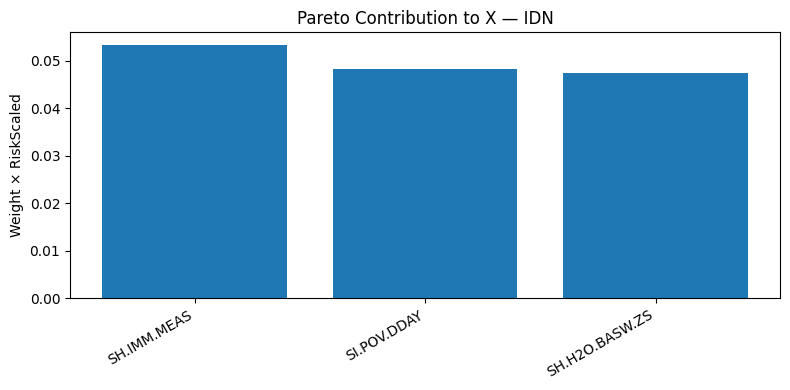

/tmp/ipython-input-2182516321.py:45: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




✔ Save (Versi SSS): /content/output/dv4_gap_frontier_SSS.png


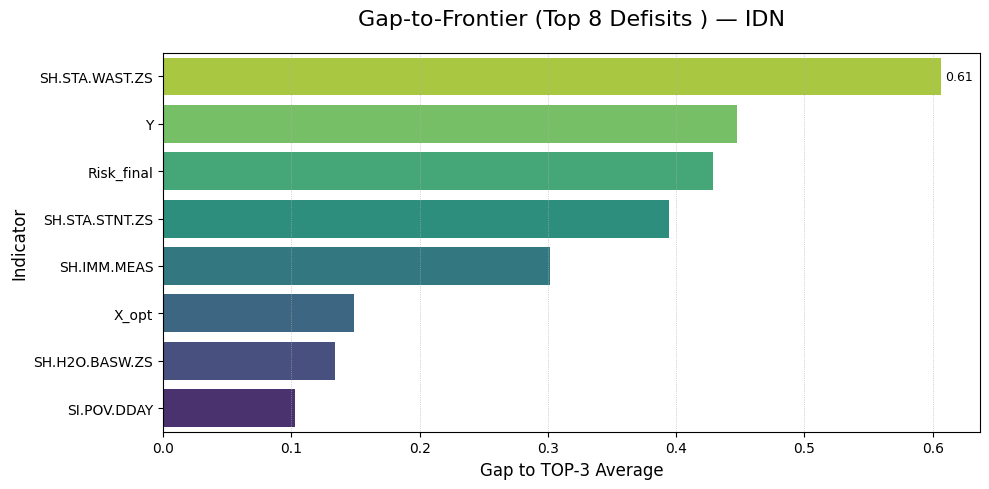

In [ ]:
# ==========================================================
# 8. PARETO KONTRIBUSI X (FOCUS_CC) & 9. GAP-TO-FRONTIER
# ==========================================================
# Pareto
ri_latest = pivot_latest[pivot_latest["Country Code"]==FOCUS_CC]
if len(ri_latest):
    contrib_x = []
    for k,w in weight_x.items():
        contrib_x.append((k, w*float(ri_latest[k].values[0])))
    contrib_x = pd.DataFrame(contrib_x, columns=["Code","Contribution"]).sort_values("Contribution", ascending=False)
    plt.figure(figsize=(8,4))
    plt.bar(contrib_x["Code"], contrib_x["Contribution"])
    plt.title(f"Pareto Contribution to X — {FOCUS_CC}")
    plt.xticks(rotation=30, ha="right"); plt.ylabel("Weight × RiskScaled")
    plt.tight_layout(); png_pareto = os.path.join(OUT_DIR, "pareto_kontribusi.png")
    plt.savefig(png_pareto, dpi=300); print("✔ Save:", png_pareto); plt.show()

# ==========================================================
# PERBAIKAN SSS-TIER UNTUK CELL 10 (GAP-TO-FRONTIER)
# ==========================================================
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate gaps before plotting
N_FRONTIER = 3
items = list(set([*ALL_CODES, "X_opt" if "X_opt" in pivot_latest else "X", "Y_opt" if "Y_latest" in pivot_latest else "Y", "Risk_final" if "Risk_final" in pivot_latest.columns else "Risk"]))
focus_cc = FOCUS_CC
recs = []
for code in items:
    if code not in pivot_latest.columns:
        continue
    series = pivot_latest[code].astype(float)
    topN = series.nsmallest(min(N_FRONTIER, series.notna().sum())).mean()
    try:
        idn_val = float(pivot_latest.loc[pivot_latest["Country Code"]==focus_cc, code].values[0])
    except:
        idn_val = np.nan
    recs.append({"Item": code, "IDN": idn_val, "Frontier": topN, "Gap": idn_val-topN})
gaps = pd.DataFrame(recs).dropna().sort_values("Gap", ascending=False).head(8)


# (Pastikan 'gaps' DataFrame sudah ada dari baris di atasnya di cell 10)

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=gaps,
    x="Gap",               # <-- Sumbu X untuk nilai
    y="Item",              # <-- Sumbu Y untuk kategori (lebih mudah dibaca)
    palette="viridis_r"    # <-- Palet warna SSS (makin besar gap, makin 'panas')
)

# Memberi label nilai di ujung bar
ax.bar_label(ax.containers[0], fmt='%.2f', padding=3, fontsize=9)

ax.set_title(f"Gap-to-Frontier (Top 8 Defisits ) — {focus_cc}", fontsize=16, pad=20)
ax.set_xlabel("Gap to TOP-3 Average", fontsize=12)
ax.set_ylabel("Indicator", fontsize=12)
plt.grid(True, axis='x', linestyle=":", linewidth=0.5, zorder=0)

# Simpan file (seperti di kode asli)
out_png = os.path.join(OUT_DIR, "dv4_gap_frontier_SSS.png")
plt.tight_layout()
plt.savefig(out_png, dpi=300)
print("✔ Save (Versi SSS):", out_png)
plt.show()

/tmp/ipython-input-1970609956.py:7: FutureWarning:

DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.



✔ Save: /content/output/target2030_tren.png


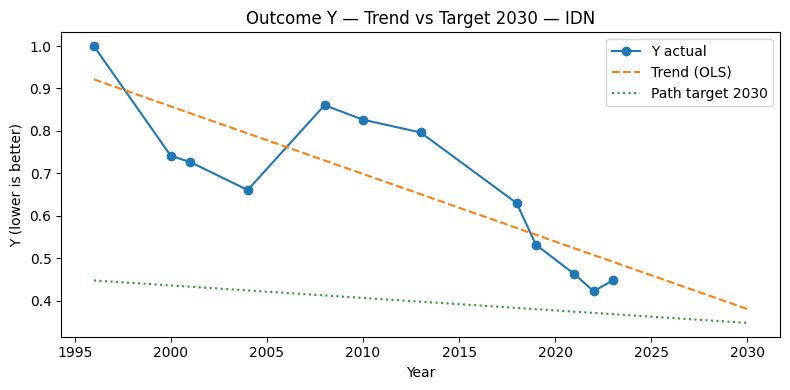

In [ ]:

# ==========================================================
# 10. TARGET 2030 vs TREN (Y, RiskScaled) — FOCUS_CC
# ==========================================================
idn_scaled = scaled[(scaled["Country Code"]==FOCUS_CC) & (scaled["Indicator Code"].isin(CODES_Y))].copy()
idn_scaled["Year"] = idn_scaled["Year"].astype(int)
idn_piv = idn_scaled.pivot_table(index="Year", columns="Indicator Code", values="RiskScaled", aggfunc="first")
idn_piv = idn_piv.sort_index().fillna(method="ffill")

idn_piv["Y"] = 0.0
for k,w in WEIGHT_Y.items():
    if k in idn_piv.columns: idn_piv["Y"] += w*idn_piv[k]

if len(idn_piv) >= 3:
    last = idn_piv.tail(SLOPE_WINDOW)
    x = last.index.values.astype(float); y = last["Y"].values.astype(float)
    b1, b0 = np.polyfit(x, y, 1)

    delta_target = 0.10  # contoh target penurunan 0.10 unit risiko
    y_now = float(idn_piv["Y"].iloc[-1]); year_target = 2030
    xs = np.arange(idn_piv.index.min(), year_target+1)
    y_trend = b0 + b1*xs
    y_line_target = np.linspace(y_now, max(0.0, y_now-delta_target), len(xs))

    plt.figure(figsize=(8,4))
    plt.plot(idn_piv.index.values, idn_piv["Y"].values, marker="o", label="Y actual")
    plt.plot(xs, y_trend, linestyle="--", label="Trend (OLS)")
    plt.plot(xs, y_line_target, linestyle=":", label="Path target 2030")
    plt.title(f"Outcome Y — Trend vs Target 2030 — {FOCUS_CC}")
    plt.xlabel("Year"); plt.ylabel("Y (lower is better)"); plt.legend()
    plt.tight_layout(); png_tgt = os.path.join(OUT_DIR, "target2030_tren.png")
    plt.savefig(png_tgt, dpi=300); print("✔ Save:", png_tgt); plt.show()
else:
    print("(Skip) Y time series is too short untuk tren-target.")


In [ ]:
print("Weight X (opt):", weight_x_opt)
print("Weight Y (opt):", WEIGHT_Y_OPT)
print("Risk_AGGR (opt):", RISK_AGGR_OPT)

Weight X (opt): Indicator Code
SI.POV.DDAY      0.4706
SH.H2O.BASW.ZS   0.3529
SH.IMM.MEAS      0.1765
dtype: float64
Weight Y (opt): {'SH.STA.STNT.ZS': 0.4999999999999992, 'SH.STA.WAST.ZS': 0.5000000000000008}
Risk_AGGR (opt): (0.7999999999999998, 0.20000000000000018)


In [ ]:

# ==========================================================
# 12F. EVALUASI RINGKAS — MONOTONISITAS, SEPARATION, STABILITAS
# ==========================================================
def spearman_s(x, y):
    return float(pd.Series(x).corr(pd.Series(y), method='spearman'))

print("Spearman(X_opt, Y_opt):", spearman_s(pivot_latest["X_opt"], pivot_latest["Y_opt"]))
print("Spearman(Risk_final, Y_opt):", spearman_s(pivot_latest["Risk_final"], pivot_latest["Y_opt"]))
print("Std(X_opt):", float(pivot_latest["X_opt"].std(ddof=0)))
print("Std(Risk_final):", float(pivot_latest["Risk_final"].std(ddof=0)))
if "X" in pivot_latest.columns:
    print("Spearman(X_opt, X_expert):", spearman_s(pivot_latest["X_opt"], pivot_latest["X"]))


Spearman(X_opt, Y_opt): 0.5931067713418846
Spearman(Risk_final, Y_opt): 0.9577804692693648
Std(X_opt): 0.24835191296952658
Std(Risk_final): 0.20090878742394797
Spearman(X_opt, X_expert): 1.0


In [ ]:
# === TABEL X_opt & Y_opt per negara (seluruh cakupan data yang kamu pakai) ===
# pastikan summary_opt sudah ada:
# summary_opt = summary.merge(pivot_latest[["Country Code","Country Name","X_opt","Y_opt","Risk_final"]], ...)

tbl = (
    summary_opt[["Country Code","Country Name","X_opt","Y_opt","Risk_final"]]
    .copy()
)

# Bulatkan 4 desimal (sesuai preferensi)
tbl["X_opt"]      = tbl["X_opt"].astype(float).round(4)
tbl["Y_opt"]      = tbl["Y_opt"].astype(float).round(4)
tbl["Risk_final"] = tbl["Risk_final"].astype(float).round(4)

# Urutkan (ganti sesuai selera: "Risk_final", "Country Code", dsb.)
tbl = tbl.sort_values(["Risk_final"]).reset_index(drop=True)

# Print rapi semua baris
print(tbl.to_string(index=False))

# Simpan ke CSV
csv_all = os.path.join(OUT_DIR, "xopt_yopt_by_country.csv")
tbl.to_csv(csv_all, index=False)
print("✔ Save:", csv_all)


Country Code                                                              Country Name  X_opt  Y_opt  Risk_final
         DEU                                                                   Germany 0.0042 0.0000      0.0008
         KOR                                                               Korea, Rep. 0.0042 0.0000      0.0008
         BEL                                                                   Belgium 0.0067 0.0000      0.0013
         MLT                                                                     Malta 0.0100 0.0000      0.0020
         CHL                                                                     Chile 0.0170 0.0000      0.0034
         PRT                                                                  Portugal 0.0069 0.0041      0.0046
         AUS                                                                 Australia 0.0272 0.0000      0.0054
         TON                                                                     Tonga 0.0123 0.

# Statistik ringkas risk_final
  n    min    p10     q1  median   mean     q3    p90    max    std     cv   skew
264 0.0008 0.0643 0.1320  0.1821 0.2542 0.3621 0.5487 0.9953 0.2009 0.7904 1.3440

# TOP 15 risk_final (tinggi = lebih berisk)
Country Code     Country Name  Risk_final  X_opt  Y_opt
         PNG Papua New Guinea      0.9953 0.9767 1.0000
         YEM      Yemen, Rep.      0.9572 0.7860 1.0000
         NER            Niger      0.8974 0.8835 0.9009
         ERI          Eritrea      0.8805 0.4024 1.0000
         SSD      South Sudan      0.8260 0.9101 0.8050
         SDN            Sudan      0.8139 0.5295 0.8850
         BDI          Burundi      0.7854 0.8124 0.7787
         COD Congo, Dem. Rep.      0.7669 0.9767 0.7144
         TLS      Timor-Leste      0.7446 0.5923 0.7827
         NGA          Nigeria      0.7348 0.6006 0.7684
         MDG       Madagascar      0.7221 0.9800 0.6576
         IND            India      0.7065 0.1178 0.8537
         SOM          Somalia   

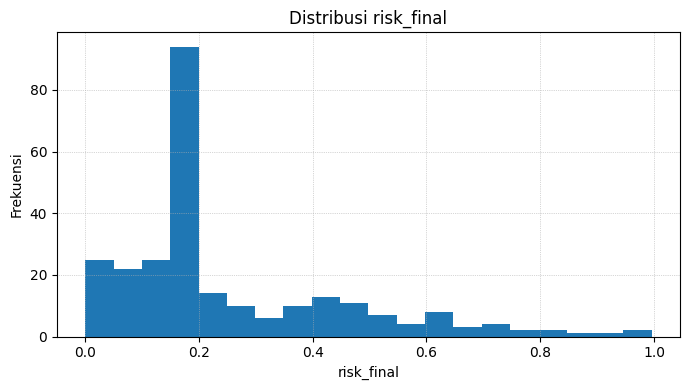


✔ Tersimpan:
 - risk_final_summary_stats.csv
 - risk_final_top15.csv, risk_final_bottom15.csv
 - risk_final_bucket_counts.csv
 - risk_final_correlations.csv
 - risk_final_hist.png


In [ ]:
# ==========================================================
# SUMMARY RISK_FINAL (statistik, ranking, bucket, korelasi)
# ==========================================================
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt

# Folder output aman
try:
    OUT_DIR
except NameError:
    OUT_DIR = "/content/output"
os.makedirs(OUT_DIR, exist_ok=True)

# ----- 1) Ambil kolom yang dibutuhkan -----
if "summary_opt" not in globals():
    raise RuntimeError("summary_opt belum ada. Jalankan notebook utama dulu.")

df = summary_opt.copy()
col = "Risk_final" if "Risk_final" in df.columns else ("Risk" if "Risk" in df.columns else None)
if col is None:
    raise RuntimeError("Tidak menemukan kolom Risk_final / Risk di summary_opt.")

# Pastikan numerik & drop NA
df[col] = pd.to_numeric(df[col], errors="coerce")
df_stats = df.dropna(subset=[col]).copy()

# ----- 2) Statistik ringkas -----
stats = {
    "n": int(df_stats[col].notna().sum()),
    "min": float(df_stats[col].min()),
    "p10": float(df_stats[col].quantile(0.10)),
    "q1" : float(df_stats[col].quantile(0.25)),
    "median": float(df_stats[col].median()),
    "mean": float(df_stats[col].mean()),
    "q3" : float(df_stats[col].quantile(0.75)),
    "p90": float(df_stats[col].quantile(0.90)),
    "max": float(df_stats[col].max()),
    "std": float(df_stats[col].std(ddof=0)),
}
stats["cv"]   = float(stats["std"]/stats["mean"]) if stats["mean"] != 0 else np.nan
# skewness aman (tambah epsilon agar tidak div0)
std_eps = stats["std"] if stats["std"] > 1e-12 else 1e-12
skew = ((df_stats[col]-stats["mean"])**3).mean() / (std_eps**3)
stats["skew"] = float(skew)

stats_df = pd.DataFrame([stats]).round(4)
print("# Statistik ringkas risk_final")
print(stats_df.to_string(index=False))

# Simpan
stats_df.to_csv(os.path.join(OUT_DIR, "risk_final_summary_stats.csv"), index=False)

# ----- 3) Ranking TOP/BOTTOM -----
cols_show = [c for c in ["Country Code","Country Name",col,"X_opt","Y_opt"] if c in df_stats.columns]
topN = df_stats.sort_values(col, ascending=False).head(15)[cols_show].reset_index(drop=True).round(4)
botN = df_stats.sort_values(col, ascending=True ).head(15)[cols_show].reset_index(drop=True).round(4)
print("\n# TOP 15 risk_final (tinggi = lebih berisk)")
print(topN.to_string(index=False))
print("\n# BOTTOM 15 risk_final (rendah = lebih baik)")
print(botN.to_string(index=False))

topN.to_csv(os.path.join(OUT_DIR, "risk_final_top15.csv"), index=False)
botN.to_csv(os.path.join(OUT_DIR, "risk_final_bottom15.csv"), index=False)

# ----- 4) Bucket kuantil (5 tingkat) -----
labels5 = ["Very Low","Low","Medium","High","Very High"]
try:
    df_stats["risk_bucket"] = pd.qcut(
        df_stats[col].rank(method="first"), q=5, labels=labels5, duplicates="drop"
    )
except Exception:
    # fallback aman kalau data terlalu sedikit/terikat
    q = min(5, max(2, df_stats.shape[0]//3))
    df_stats["risk_bucket"] = pd.qcut(
        df_stats[col].rank(method="first"), q=q, labels=labels5[:q], duplicates="drop"
    )
bucket_counts = df_stats["risk_bucket"].value_counts().reindex(labels5).fillna(0).astype(int)
bucket_df = bucket_counts.rename_axis("bucket").reset_index(name="n")
print("\n# Distribusi bucket (kuantil)")
print(bucket_df.to_string(index=False))

bucket_df.to_csv(os.path.join(OUT_DIR, "risk_final_bucket_counts.csv"), index=False)

# ----- 5) Korelasi (Spearman) dengan Y_opt & X_opt (jika ada) -----
def spearman_safe(a, b):
    a = pd.to_numeric(a, errors="coerce")
    b = pd.to_numeric(b, errors="coerce")
    m = a.notna() & b.notna()
    return float(a[m].corr(b[m], method="spearman")) if m.sum() >= 3 else np.nan

corrs = {}
if "Y_opt" in df_stats.columns:
    corrs["spearman_risk_vs_Y"] = spearman_safe(df_stats[col], df_stats["Y_opt"])
if "X_opt" in df_stats.columns:
    corrs["spearman_risk_vs_X"] = spearman_safe(df_stats[col], df_stats["X_opt"])
if corrs:
    corr_df = pd.DataFrame([corrs]).round(4)
    print("\n# Korelasi Spearman")
    print(corr_df.to_string(index=False))
    corr_df.to_csv(os.path.join(OUT_DIR, "risk_final_correlations.csv"), index=False)

# ----- 6) Histogram sederhana -----
plt.figure(figsize=(7,4))
plt.hist(df_stats[col].astype(float).values, bins=20)
plt.xlabel("risk_final")
plt.ylabel("Frekuensi")
plt.title("Distribusi risk_final")
plt.grid(True, linestyle=":", linewidth=0.5)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "risk_final_hist.png"), dpi=300)
plt.show()

print("\n✔ Tersimpan:")
print(" - risk_final_summary_stats.csv")
print(" - risk_final_top15.csv, risk_final_bottom15.csv")
print(" - risk_final_bucket_counts.csv")
if corrs:
    print(" - risk_final_correlations.csv")
print(" - risk_final_hist.png")


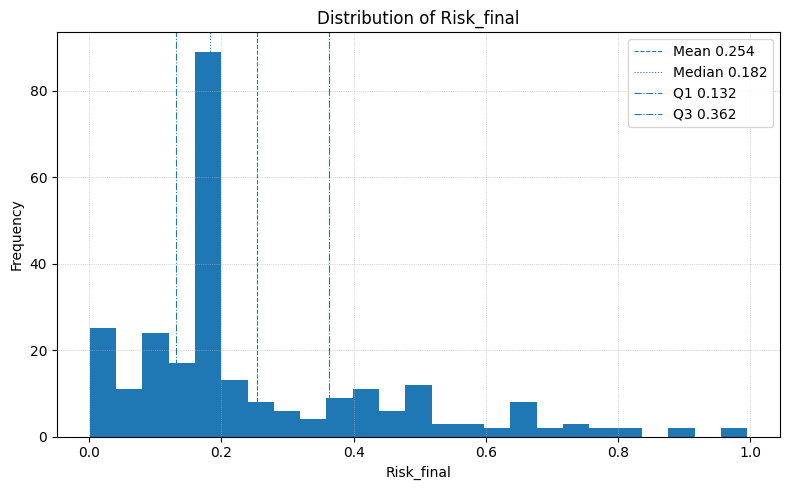

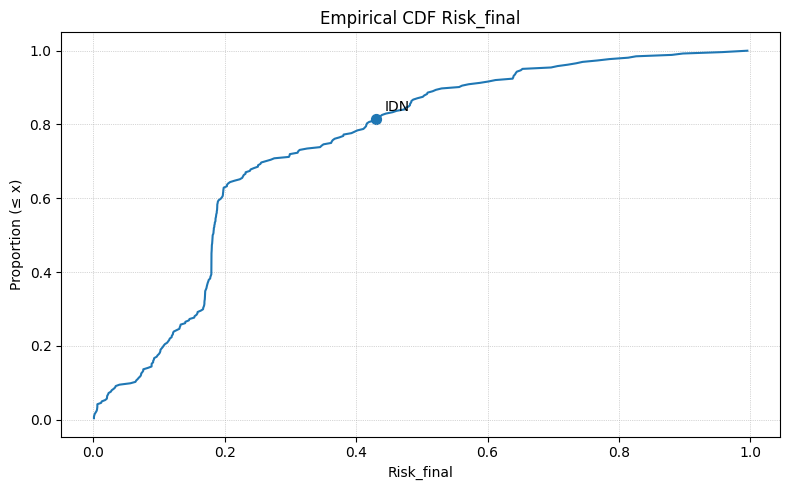

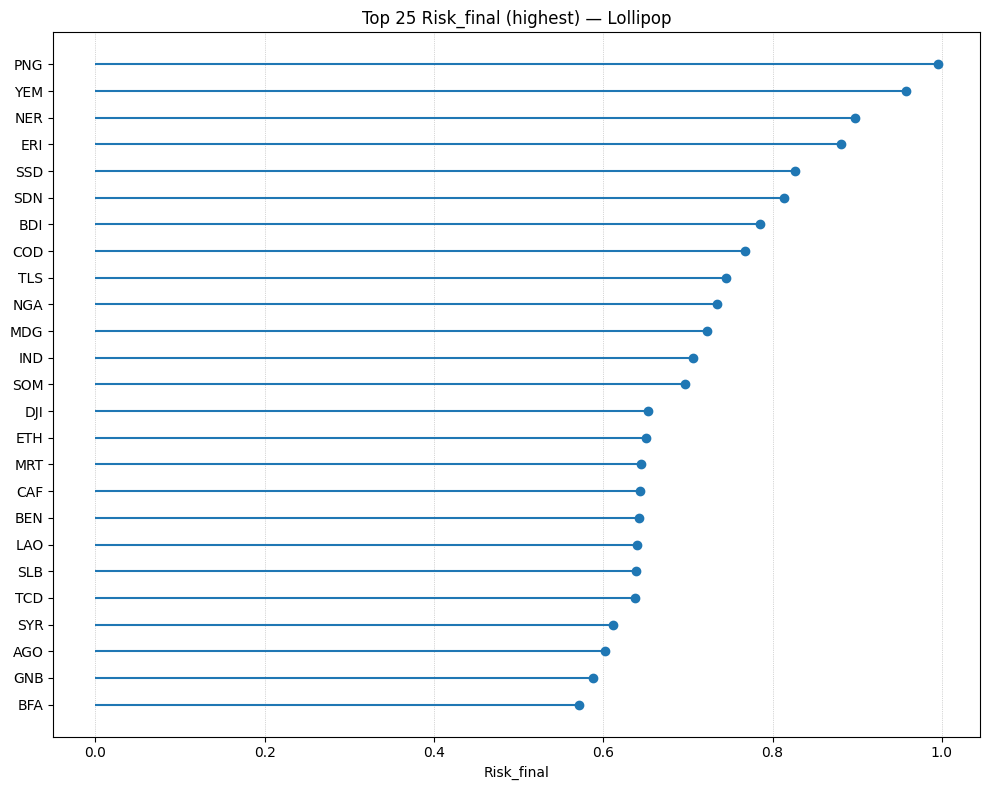

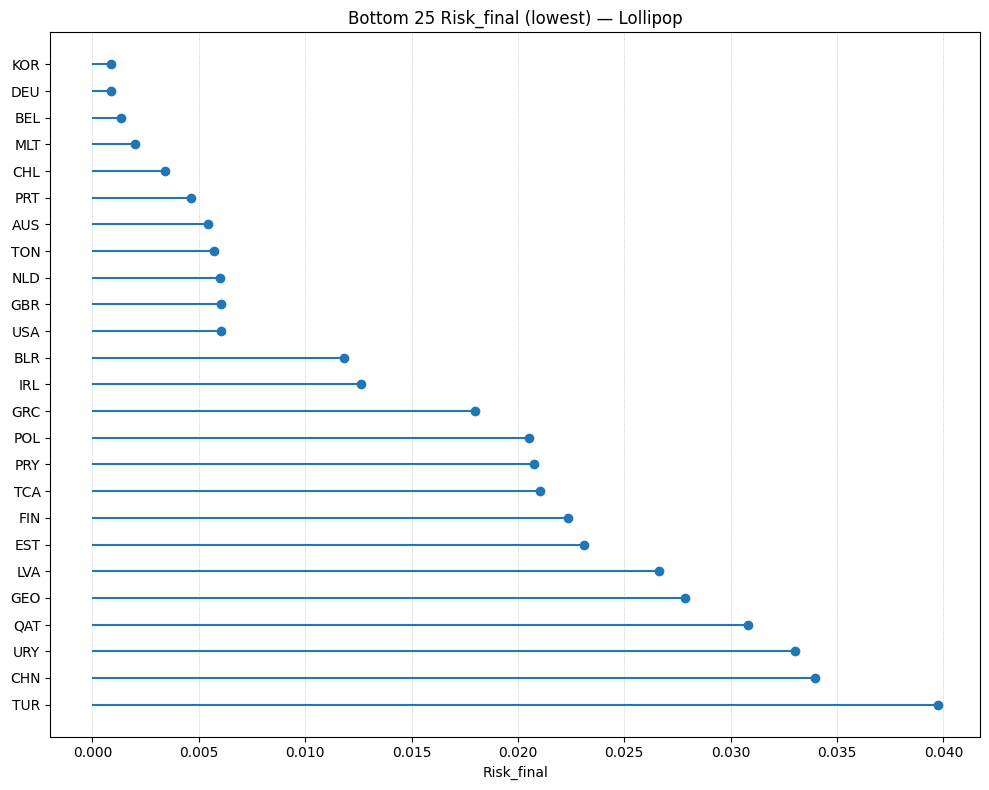

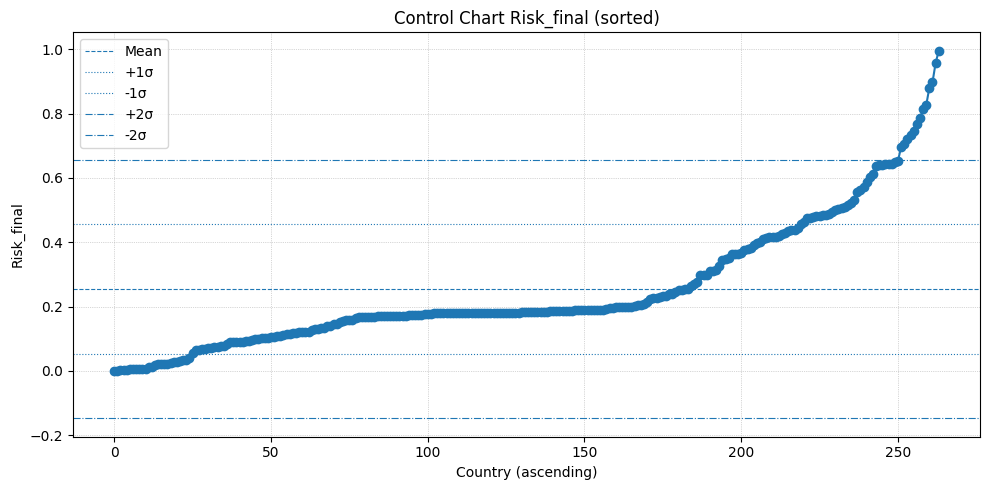

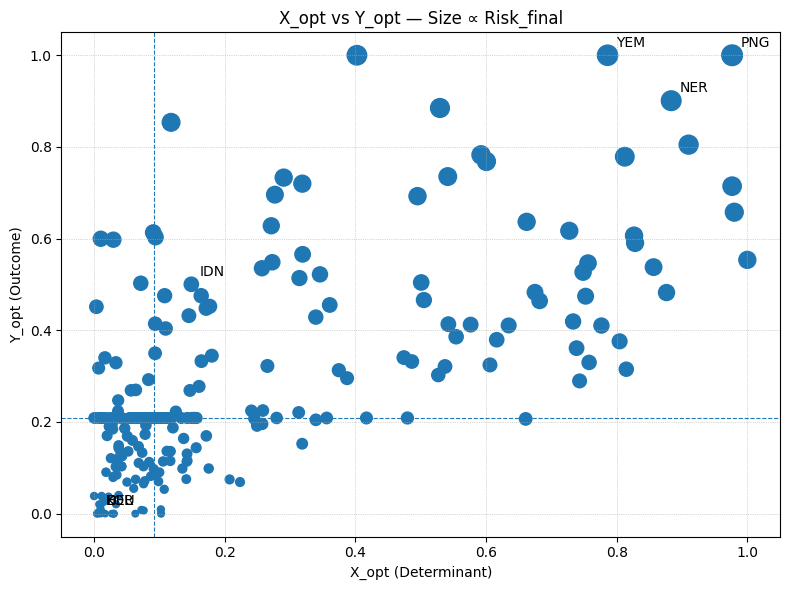

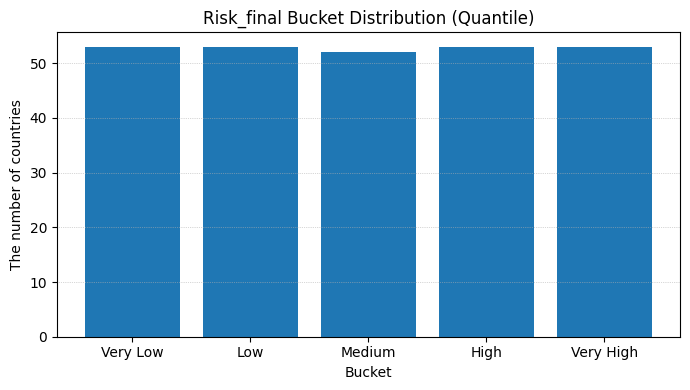

✔ Berkas disimpan di: /content/output


In [ ]:
# ===== Risk_final Visualization Pack (matplotlib-only) =====
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt

df = summary_opt.copy()
risk_col = 'Risk_final' if 'Risk_final' in df.columns else ('Risk' if 'Risk' in df.columns else None)
assert risk_col is not None, "risk_final/Risk not found."
OUT_DIR = OUT_DIR if 'OUT_DIR' in globals() else "/content/output"
os.makedirs(OUT_DIR, exist_ok=True)

df[risk_col] = pd.to_numeric(df[risk_col], errors='coerce')
df = df.dropna(subset=[risk_col]).copy()
if 'Country Name' not in df.columns:
    df['Country Name'] = df.get('Country Code', pd.Series(range(len(df)))).astype(str)

mean_v, median_v = float(df[risk_col].mean()), float(df[risk_col].median())
q1, q3 = float(df[risk_col].quantile(0.25)), float(df[risk_col].quantile(0.75))
std_v   = float(df[risk_col].std(ddof=0))

labels5 = ["Very Low","Low","Medium","High","Very High"]
try:
    df["risk_bucket"] = pd.qcut(df[risk_col].rank(method="first"), q=5, labels=labels5, duplicates="drop")
except Exception:
    q = min(5, max(2, df.shape[0]//3))
    df["risk_bucket"] = pd.qcut(df[risk_col].rank(method="first"), q=q, labels=labels5[:q], duplicates="drop")

rank_df = df[['Country Code','Country Name',risk_col]].sort_values(risk_col, ascending=False).reset_index(drop=True)
rank_df.to_csv(os.path.join(OUT_DIR, "risk_final_ranking.csv"), index=False)

# 1) Histogram
plt.figure(figsize=(8,5))
plt.hist(df[risk_col].astype(float).values, bins=25)
plt.axvline(mean_v, linestyle='--', linewidth=0.8, label=f"Mean {mean_v:.3f}")
plt.axvline(median_v, linestyle=':',  linewidth=0.8, label=f"Median {median_v:.3f}")
plt.axvline(q1, linestyle='-.', linewidth=0.8, label=f"Q1 {q1:.3f}")
plt.axvline(q3, linestyle='-.', linewidth=0.8, label=f"Q3 {q3:.3f}")
plt.title("Distribution of Risk_final"); plt.xlabel("Risk_final"); plt.ylabel("Frequency")
plt.legend(); plt.grid(True, linestyle=":", linewidth=0.5)
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "risk_final_hist.png"), dpi=300); plt.show()

# 2) ECDF + posisi IDN jika ada
x = np.sort(df[risk_col].astype(float).values); y = np.arange(1, len(x)+1)/len(x)
plt.figure(figsize=(8,5)); plt.plot(x, y)
if 'FOCUS_CC' in globals() and 'Country Code' in df.columns:
    r = df[df['Country Code']==FOCUS_CC]
    if not r.empty:
        fx = float(r[risk_col].values[0]); fy = (x<=fx).mean()
        plt.scatter([fx],[fy], s=50); plt.annotate(FOCUS_CC, (fx, fy), textcoords="offset points", xytext=(6,6))
plt.title("Empirical CDF Risk_final"); plt.xlabel("Risk_final"); plt.ylabel("Proportion (≤ x)")
plt.grid(True, linestyle=":", linewidth=0.5)
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "risk_final_ecdf.png"), dpi=300); plt.show()

# 3) Lollipop Top 25
topN = rank_df.head(min(25, len(rank_df))); ypos = np.arange(len(topN))[::-1]
plt.figure(figsize=(10,8)); plt.hlines(y=ypos, xmin=0, xmax=topN[risk_col].values); plt.plot(topN[risk_col].values, ypos, 'o')
plt.yticks(ypos, topN.get('Country Code', topN['Country Name']).astype(str).values)
plt.xlabel("Risk_final"); plt.title("Top 25 Risk_final (highest) — Lollipop")
plt.grid(True, axis='x', linestyle=":", linewidth=0.5)
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "risk_final_top25_lollipop.png"), dpi=300); plt.show()

# 4) Lollipop Bottom 25
botN = rank_df.tail(min(25, len(rank_df))).iloc[::-1].reset_index(drop=True); ypos = np.arange(len(botN))[::-1]
plt.figure(figsize=(10,8)); plt.hlines(y=ypos, xmin=0, xmax=botN[risk_col].values); plt.plot(botN[risk_col].values, ypos, 'o')
plt.yticks(ypos, botN.get('Country Code', botN['Country Name']).astype(str).values)
plt.xlabel("Risk_final"); plt.title("Bottom 25 Risk_final (lowest) — Lollipop")
plt.grid(True, axis='x', linestyle=":", linewidth=0.5)
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "risk_final_bottom25_lollipop.png"), dpi=300); plt.show()

# 5) Control chart
srt = rank_df.sort_values(risk_col).reset_index(drop=True)
plt.figure(figsize=(10,5)); plt.plot(srt[risk_col].values, marker='o', linestyle='-')
plt.axhline(mean_v, linestyle='--', linewidth=0.8, label='Mean')
plt.axhline(mean_v+std_v, linestyle=':', linewidth=0.8, label='+1σ')
plt.axhline(mean_v-std_v, linestyle=':', linewidth=0.8, label='-1σ')
plt.axhline(mean_v+2*std_v, linestyle='-.', linewidth=0.8, label='+2σ')
plt.axhline(mean_v-2*std_v, linestyle='-.', linewidth=0.8, label='-2σ')
plt.title("Control Chart Risk_final (sorted)"); plt.xlabel("Country (ascending)"); plt.ylabel("Risk_final")
plt.legend(); plt.grid(True, linestyle=":", linewidth=0.5)
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "risk_final_control_chart.png"), dpi=300); plt.show()

# 6) Scatter X_opt vs Y_opt (size ∝ risk_final)
if ('X_opt' in df.columns) and ('Y_opt' in df.columns):
    plt.figure(figsize=(8,6))
    s = 200 * (df[risk_col].astype(float).values / (df[risk_col].max() or 1.0)) + 20
    plt.scatter(df['X_opt'].astype(float).values, df['Y_opt'].astype(float).values, s=s)
    xm, ym = df['X_opt'].median(), df['Y_opt'].median()
    plt.axvline(xm, linestyle='--', linewidth=0.8); plt.axhline(ym, linestyle='--', linewidth=0.8)
    if 'Country Code' in df.columns:
        mark = set()
        if 'FOCUS_CC' in globals(): mark.add(FOCUS_CC)
        mark |= set(rank_df.head(3)['Country Code']) | set(rank_df.tail(3)['Country Code'])
        for _, r in df[df['Country Code'].isin(mark)].iterrows():
            plt.annotate(str(r['Country Code']), (float(r['X_opt']), float(r['Y_opt'])), textcoords="offset points", xytext=(6,6))
    plt.xlabel("X_opt (Determinant)"); plt.ylabel("Y_opt (Outcome)"); plt.title("X_opt vs Y_opt — Size ∝ Risk_final")
    plt.grid(True, linestyle=":", linewidth=0.5)
    plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "risk_final_scatter_XY_size.png"), dpi=300); plt.show()

# 7) Bar bucket kuantil
bc = df['risk_bucket'].value_counts().reindex(labels5).fillna(0).astype(int)
plt.figure(figsize=(7,4)); plt.bar(bc.index.astype(str), bc.values)
plt.title("Risk_final Bucket Distribution (Quantile)"); plt.xlabel("Bucket"); plt.ylabel("The number of countries")
plt.grid(True, axis='y', linestyle=":", linewidth=0.5)
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "risk_final_bucket_counts.png"), dpi=300); plt.show()

print("✔ Berkas disimpan di:", OUT_DIR)


Metode klaster: kmeans (k=2, silhouette=0.7182)
Country Code                                                              Country Name  X_opt  Y_opt  Risk_final  risk_cluster risk_bucket
         KOR                                                               Korea, Rep. 0.0042 0.0000      0.0008             1         Low
         DEU                                                                   Germany 0.0042 0.0000      0.0008             1         Low
         BEL                                                                   Belgium 0.0067 0.0000      0.0013             1         Low
         MLT                                                                     Malta 0.0100 0.0000      0.0020             1         Low
         CHL                                                                     Chile 0.0170 0.0000      0.0034             1         Low
         PRT                                                                  Portugal 0.0069 0.0041      0.0046      

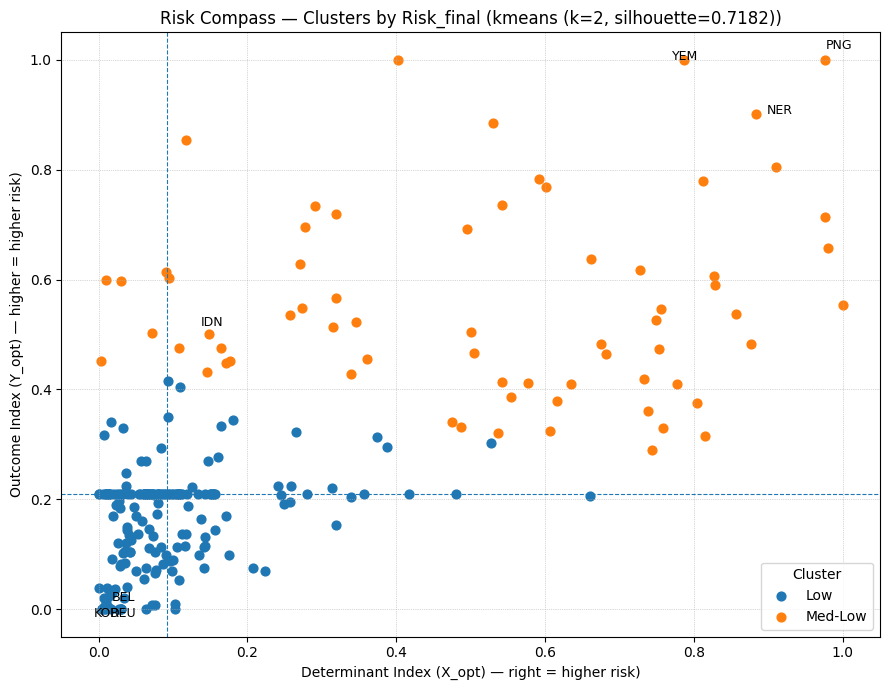

In [ ]:
# ==========================================================
# 13. CLUSTERING BERDASARKAN Risk_final
# ==========================================================
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Siapkan data (pastikan summary_opt sudah ada)
df = summary_opt[["Country Code","Country Name","X_opt","Y_opt","Risk_final"]].dropna().copy()
Z = df[["Risk_final"]].values

# Pilih K terbaik dengan silhouette
max_k = min(8, max(3, len(df)-1))  # aman untuk sampel kecil
best_k, best_score, best_model = None, -1.0, None
for k in range(2, max_k+1):
    try:
        km = KMeans(n_clusters=k, n_init=10, random_state=42)
        lab = km.fit_predict(Z)
        if len(set(lab)) < 2:
            continue
        s = silhouette_score(Z, lab)
        if s > best_score:
            best_k, best_score, best_model = k, s, km
    except Exception as e:
        pass

if best_model is None:
    # Fallback: gunakan quantile (4 bucket)
    df["risk_cluster"] = pd.qcut(df["Risk_final"], q=4, labels=[1,2,3,4]).astype(int)
    method_info = "quantile (q=4)"
else:
    # KMeans: mapping cluster → urutan risiko (rendah=1 ... tinggi=K)
    raw_lab = best_model.predict(Z)                       # cluster id acak
    centers = pd.Series(best_model.cluster_centers_.ravel())
    order = centers.sort_values().index.tolist()          # index cluster dari rendah→tinggi
    remap = {old:i+1 for i, old in enumerate(order)}      # jadikan 1..K
    df["risk_cluster"] = pd.Series(raw_lab, index=df.index).map(remap)
    method_info = f"kmeans (k={best_k}, silhouette={best_score:.4f})"

# Label teks untuk presentasi
label_names = {1:"Low", 2:"Med-Low", 3:"Med-High", 4:"High", 5:"Very High", 6:"Extreme"}
df["risk_bucket"] = df["risk_cluster"].map(lambda r: label_names.get(int(r), f"Group-{int(r)}"))

# Ringkasan & simpan
out_csv = os.path.join(OUT_DIR, "risk_clusters_by_country.csv")
df_out = df[["Country Code","Country Name","X_opt","Y_opt","Risk_final","risk_cluster","risk_bucket"]].copy()
df_out = df_out.sort_values(["risk_cluster","Risk_final"]).reset_index(drop=True)
df_out["X_opt"] = df_out["X_opt"].round(4)
df_out["Y_opt"] = df_out["Y_opt"].round(4)
df_out["Risk_final"] = df_out["Risk_final"].round(4)

print(f"Metode klaster: {method_info}")
print(df_out.to_string(index=False))
df_out.to_csv(out_csv, index=False)
print("✔ Save:", out_csv)

# Plot kompas berwarna per klaster
plt.figure(figsize=(9,7))
for g, gdf in df.groupby("risk_bucket"):
    plt.scatter(gdf["X_opt"], gdf["Y_opt"], s=40, label=g)  # warna default per grup

# garis kuadran (median)
xm, ym = df["X_opt"].median(), df["Y_opt"].median()
plt.axvline(xm, linestyle="--", linewidth=0.8)
plt.axhline(ym, linestyle="--", linewidth=0.8)

# anotasi fokus + top/bottom
FOCUS_CC = FOCUS_CC if "FOCUS_CC" in globals() else "IDN"
lab_focus = {FOCUS_CC}
lab_top3  = set(df.nlargest(3, "Risk_final")["Country Code"])
lab_bot3  = set(df.nsmallest(3, "Risk_final")["Country Code"])
LAB_SET   = lab_focus | lab_top3 | lab_bot3

OFFSETS = [(6,6),(6,-6),(-6,6),(-6,-6),(8,0),(0,8),(-8,0),(0,-8)]
k = 0
for _, r in df.iterrows():
    if r["Country Code"] in LAB_SET:
        dx, dy = OFFSETS[k % len(OFFSETS)]; k += 1
        plt.annotate(r["Country Code"], (float(r["X_opt"]), float(r["Y_opt"])),
                     textcoords="offset points", xytext=(dx, dy), fontsize=9)

plt.xlabel("Determinant Index (X_opt) — right = higher risk)")
plt.ylabel("Outcome Index (Y_opt) — higher = higher risk)")
plt.title(f"Risk Compass — Clusters by Risk_final ({method_info})")
plt.grid(True, linestyle=":", linewidth=0.5)
plt.legend(title="Cluster", loc="best")
png = os.path.join(OUT_DIR, "compass_scatter_clusters.png")
plt.tight_layout(); plt.savefig(png, dpi=300)
print("✔ Save:", png)
plt.show()


GMM terbaik: K=3  (min BIC=-316.70)
Cluster centers (low→high): [np.float64(0.0806), np.float64(0.1811), np.float64(0.4197)]
Cluster sizes: {1: 76, 2: 92, 3: 96}
Country Code                                                              Country Name  X_opt  Y_opt  Risk_final  risk_cluster risk_bucket  p_high
         DEU                                                                   Germany 0.0042 0.0000      0.0008             1         Low  0.1467
         KOR                                                               Korea, Rep. 0.0042 0.0000      0.0008             1         Low  0.1467
         BEL                                                                   Belgium 0.0067 0.0000      0.0013             1         Low  0.1456
         MLT                                                                     Malta 0.0100 0.0000      0.0020             1         Low  0.1441
         CHL                                                                     Chile 0.0170 0.0000   

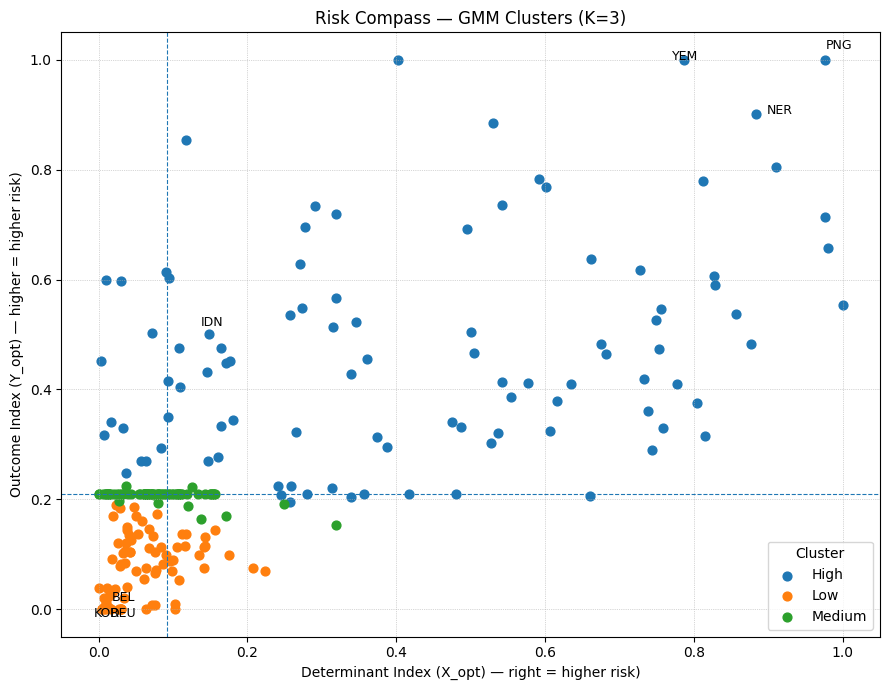

In [ ]:
# ==========================================================
# 13. GMM CLUSTERING BERDASARKAN Risk_final (soft cluster)
# ==========================================================
from sklearn.mixture import GaussianMixture
import numpy as np, pandas as pd, os, matplotlib.pyplot as plt

# --- Data sumber (pastikan summary_opt sudah ada) ---
df = summary_opt[["Country Code","Country Name","X_opt","Y_opt","Risk_final"]].dropna().copy()
X = df[["Risk_final"]].values

# --- Pilih K terbaik pakai BIC ---
Ks = list(range(2, min(7, max(3, len(df)-1)) + 1))
models, bics = [], []
for k in Ks:
    try:
        gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=42)
        gmm.fit(X)
        models.append(gmm); bics.append(gmm.bic(X))
    except Exception as e:
        pass

if not models:
    raise RuntimeError("GMM gagal fit: data terlalu sedikit atau semua Risk_final NaN.")

best = models[int(np.argmin(bics))]
K = best.n_components
means = best.means_.ravel()                       # mean Risk_final tiap cluster (urutan asli model)
orig_labels = best.predict(X)                      # 0..K-1
proba = best.predict_proba(X)                      # probabilitas per cluster (urutan asli)

# --- Remap cluster id jadi urut Low→High: 1..K ---
order = np.argsort(means)                          # index cluster dari rendah → tinggi (urutan asli)
remap = {orig: (i+1) for i, orig in enumerate(order)}
df["risk_cluster"] = pd.Series(orig_labels, index=df.index).map(remap).astype(int)

# --- Probabilitas "High" (klaster dengan mean tertinggi) ---
orig_high = int(np.argmax(means))                  # index asli klaster high
df["p_high"] = proba[:, orig_high].round(4)

# --- Nama bucket dinamis sesuai K ---
LABEL_MAPS = {
    2: ["Low","High"],
    3: ["Low","Medium","High"],
    4: ["Low","Med-Low","Med-High","High"],
    5: ["Very Low","Low","Medium","High","Very High"],
    6: ["Very Low","Low","Med-Low","Med-High","High","Extreme"],
}
names = LABEL_MAPS.get(K, [f"Group-{i}" for i in range(1, K+1)])
df["risk_bucket"] = df["risk_cluster"].map(lambda r: names[r-1])

# --- Tambahan info/debug ---
centers_sorted = np.sort(means)                    # low→high
sizes = df["risk_cluster"].value_counts().sort_index().to_dict()
print(f"GMM terbaik: K={K}  (min BIC={min(bics):.2f})")
print("Cluster centers (low→high):", [round(c,4) for c in centers_sorted])
print("Cluster sizes:", sizes)

# --- Keluarannya: tabel rapi + CSV ---
out_cols = ["Country Code","Country Name","X_opt","Y_opt","Risk_final","risk_cluster","risk_bucket","p_high"]
out = df[out_cols].copy()
out["X_opt"] = out["X_opt"].astype(float).round(4)
out["Y_opt"] = out["Y_opt"].astype(float).round(4)
out["Risk_final"] = out["Risk_final"].astype(float).round(4)
out = out.sort_values(["risk_cluster","Risk_final"]).reset_index(drop=True)
print(out.to_string(index=False))

csv_path = os.path.join(OUT_DIR, "risk_gmm_by_country.csv")
out.to_csv(csv_path, index=False)
print("✔ Save:", csv_path)

# --- Plot kompas berwarna per klaster ---
plt.figure(figsize=(9,7))
for name, g in df.groupby("risk_bucket"):
    plt.scatter(g["X_opt"], g["Y_opt"], s=40, label=name)

# garis kuadran (median)
xm, ym = df["X_opt"].median(), df["Y_opt"].median()
plt.axvline(xm, linestyle="--", linewidth=0.8); plt.axhline(ym, linestyle="--", linewidth=0.8)

# anotasi: fokus + top/bottom Risk_final
FOCUS = FOCUS_CC if "FOCUS_CC" in globals() else "IDN"
mark = set([FOCUS]) | set(df.nlargest(3,"Risk_final")["Country Code"]) | set(df.nsmallest(3,"Risk_final")["Country Code"])
OFF = [(6,6),(6,-6),(-6,6),(-6,-6),(8,0),(0,8),(-8,0),(0,-8)]
k=0
for _, r in df.iterrows():
    if r["Country Code"] in mark:
        dx, dy = OFF[k % len(OFF)]; k += 1
        plt.annotate(r["Country Code"], (float(r["X_opt"]), float(r["Y_opt"])),
                     textcoords="offset points", xytext=(dx, dy), fontsize=9)

plt.xlabel("Determinant Index (X_opt) — right = higher risk)")
plt.ylabel("Outcome Index (Y_opt) — higher = higher risk)")
plt.title(f"Risk Compass — GMM Clusters (K={K})")
plt.grid(True, linestyle=":", linewidth=0.5)
plt.legend(title="Cluster", loc="best")

png = os.path.join(OUT_DIR, "compass_scatter_gmm.png")
plt.tight_layout(); plt.savefig(png, dpi=300)
print("✔ Save:", png)
plt.show()


In [ ]:

# =============== Guards & Utils ===============
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt

required = ["scaled","pivot_latest","summary_opt","CODES_Y","ALL_CODES","FOCUS_CC","SLOPE_WINDOW","LAST_N_YEARS","OUT_DIR"]
missing = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError("Variable berikut belum ada (jalankan notebook utama dulu): " + ", ".join(missing))

if "weight_x_opt" in globals() and isinstance(weight_x_opt, (pd.Series, dict)):
    _WEIGHT_X_FOR_DV = dict(weight_x_opt)
else:
    _WEIGHT_X_FOR_DV = dict(weight_x)

def compute_Y_for_year(cc, year):
    df = scaled[(scaled["Country Code"]==cc) & (scaled["Year"].astype(str)==str(year)) & (scaled["Indicator Code"].isin(CODES_Y))]
    if df.empty: return np.nan
    vv = 0.0
    for k,w in WEIGHT_Y.items():
        v = df.loc[df["Indicator Code"]==k, "RiskScaled"]
        if len(v): vv += w*float(v.values[0])
    return vv

def compute_X_for_year(cc, year):
    df = scaled[(scaled["Country Code"]==cc) & (scaled["Year"].astype(str)==str(year)) & (scaled["Indicator Code"].isin(_WEIGHT_X_FOR_DV.keys()))]
    if df.empty: return np.nan
    vv = 0.0
    for k,w in _WEIGHT_X_FOR_DV.items():
        v = df.loc[df["Indicator Code"]==k, "RiskScaled"]
        if len(v): vv += w*float(v.values[0])
    return vv

def bootstrap_ci(vals, q=(0.05, 0.95), n_boot=1000, rng=42):
    vals = np.array(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    if len(vals) < 3:
        return (np.nan, np.nan)
    rs = np.random.RandomState(rng)
    boots = []
    for _ in range(n_boot):
        samp = rs.choice(vals, size=len(vals), replace=True)
        boots.append(np.nanmean(samp))
    lo, hi = np.quantile(boots, q[0]), np.quantile(boots, q[1])
    return (float(lo), float(hi))


✔ Save: /content/output/dv1_compass_uncertainty.png


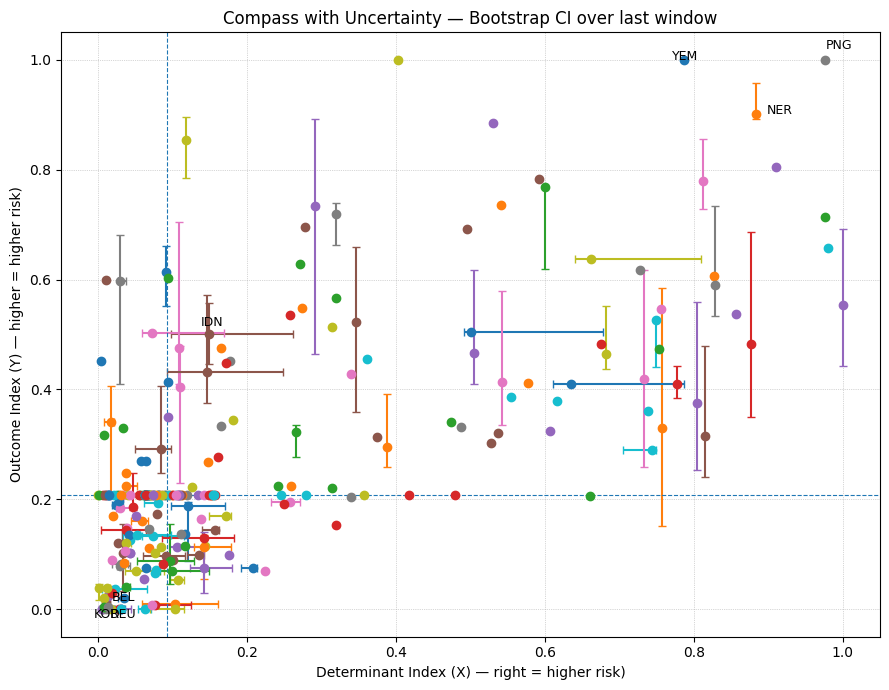

In [ ]:
scaled_years = sorted(pd.to_numeric(scaled["Year"], errors="coerce").dropna().unique())
win_years = scaled_years[-SLOPE_WINDOW:] if len(scaled_years) >= SLOPE_WINDOW else scaled_years

rows = []
for _, r in summary_opt.iterrows():
    cc = r["Country Code"]
    Y_vals = [compute_Y_for_year(cc, y) for y in win_years]
    X_vals = [compute_X_for_year(cc, y) for y in win_years]
    Y_vals = [v for v in Y_vals if np.isfinite(v)]
    X_vals = [v for v in X_vals if np.isfinite(v)]
    y_lo, y_hi = bootstrap_ci(Y_vals) if len(Y_vals)>=3 else (np.nan, np.nan)
    x_lo, x_hi = bootstrap_ci(X_vals) if len(X_vals)>=3 else (np.nan, np.nan)
    rows.append({
        "Country Code": cc,
        "X_c": float(r.get("X_opt", r["X"])),
        "Y_c": float(r.get("Y_opt", r["Y"])),
        "X_lo": x_lo, "X_hi": x_hi,
        "Y_lo": y_lo, "Y_hi": y_hi
    })
ci_tab = pd.DataFrame(rows)

plt.figure(figsize=(9,7))
for _, rr in ci_tab.iterrows():
    x, y = rr["X_c"], rr["Y_c"]
    xerr = None; yerr = None
    if np.isfinite(rr["X_lo"]) and np.isfinite(rr["X_hi"]):
        xerr = [[abs(x-rr["X_lo"])],[abs(rr["X_hi"]-x)]]
    if np.isfinite(rr["Y_lo"]) and np.isfinite(rr["Y_hi"]):
        yerr = [[abs(y-rr["Y_lo"])],[abs(rr["Y_hi"]-y)]]
    plt.errorbar(x, y, xerr=xerr, yerr=yerr, fmt='o', capsize=3)

xm = np.nanmedian(ci_tab["X_c"]); ym = np.nanmedian(ci_tab["Y_c"])
plt.axvline(xm, linestyle="--", linewidth=0.8); plt.axhline(ym, linestyle="--", linewidth=0.8)

if "Risk_final" in summary_opt.columns:
    foc = FOCUS_CC
    mark = set([foc]) | set(summary_opt.nlargest(3,"Risk_final")["Country Code"]) | set(summary_opt.nsmallest(3,"Risk_final")["Country Code"])
else:
    mark = set([FOCUS_CC])

OFF = [(6,6),(6,-6),(-6,6),(-6,-6),(8,0),(0,8),(-8,0),(0,-8)]
k=0
for _, rr in ci_tab.iterrows():
    cc = rr["Country Code"]
    if cc in mark:
        dx, dy = OFF[k % len(OFF)]; k+=1
        plt.annotate(cc, (rr["X_c"], rr["Y_c"]), textcoords="offset points", xytext=(dx, dy), fontsize=9)

plt.xlabel("Determinant Index (X) — right = higher risk)")
plt.ylabel("Outcome Index (Y) — higher = higher risk)")
plt.title("Compass with Uncertainty — Bootstrap CI over last window")
plt.grid(True, linestyle=":", linewidth=0.5)
out_png = os.path.join(OUT_DIR, "dv1_compass_uncertainty.png")
plt.tight_layout(); plt.savefig(out_png, dpi=300)
print("✔ Save:", out_png)
plt.show()

✔ Save: /content/output/dv3_pareto_X_contrib_focus.png


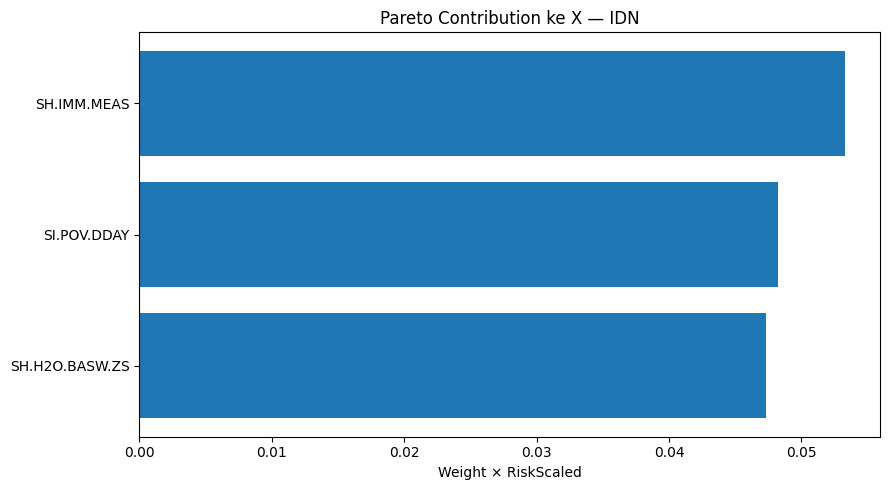

In [ ]:

focus_cc = FOCUS_CC
row = pivot_latest[pivot_latest["Country Code"]==focus_cc]
if not row.empty:
    contrib = []
    for k,w in _WEIGHT_X_FOR_DV.items():
        val = float(row[k].values[0]) if k in row.columns else np.nan
        contrib.append((k, w*val, val, w))
    dfc = pd.DataFrame(contrib, columns=["Indicator","Contribution","RiskScaled","Weight"]).sort_values("Contribution", ascending=False)

    plt.figure(figsize=(9,5))
    plt.barh(dfc["Indicator"], dfc["Contribution"])
    plt.gca().invert_yaxis()
    plt.xlabel("Weight × RiskScaled")
    plt.title(f"Pareto Contribution ke X — {focus_cc}")
    out_png = os.path.join(OUT_DIR, "dv3_pareto_X_contrib_focus.png")
    plt.tight_layout(); plt.savefig(out_png, dpi=300)
    print("✔ Save:", out_png)
    plt.show()
else:
    print("FOCUS_CC not found di pivot_latest.")


✔ Save: /content/output/dv4_gap_frontier.png


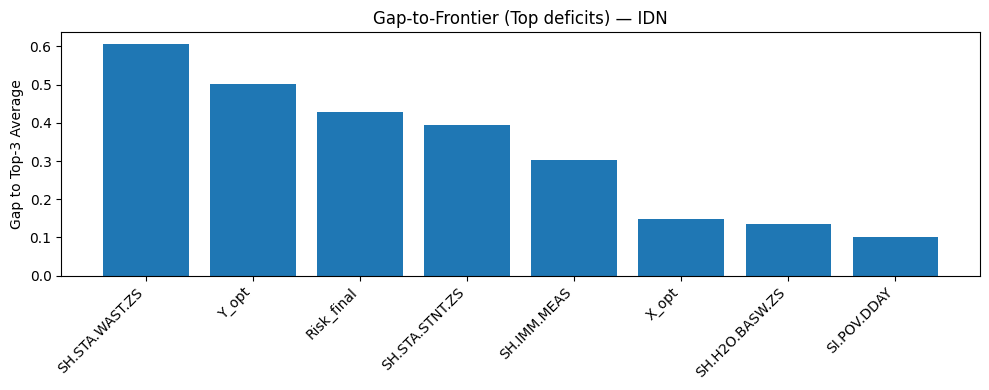

In [ ]:

N_FRONTIER = 3
items = list(set([*ALL_CODES, "X_opt" if "X_opt" in pivot_latest else "X", "Y_opt" if "Y_opt" in pivot_latest else "Y", "Risk_final" if "Risk_final" in pivot_latest.columns else "Risk"]))
focus_cc = FOCUS_CC
recs = []
for code in items:
    if code not in pivot_latest.columns:
        continue
    series = pivot_latest[code].astype(float)
    topN = series.nsmallest(min(N_FRONTIER, series.notna().sum())).mean()
    try:
        idn_val = float(pivot_latest.loc[pivot_latest["Country Code"]==focus_cc, code].values[0])
    except:
        idn_val = np.nan
    recs.append({"Item": code, "IDN": idn_val, "Frontier": topN, "Gap": idn_val-topN})
gaps = pd.DataFrame(recs).dropna().sort_values("Gap", ascending=False).head(8)

plt.figure(figsize=(10,4))
plt.bar(gaps["Item"], gaps["Gap"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Gap to Top-3 Average")
plt.title(f"Gap-to-Frontier (Top deficits) — {focus_cc}")
out_png = os.path.join(OUT_DIR, "dv4_gap_frontier.png")
plt.tight_layout(); plt.savefig(out_png, dpi=300)
print("✔ Save:", out_png)
plt.show()


### (Dari file sumber) AKHIR E NYEBLAK


In [ ]:

# Guard: pastikan variabel inti hasil pipeline ada
required = ["summary_opt","pivot_latest","scaled"]
missing = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError("Missing variables from pipeline: " + ", ".join(missing))

# Salin agar aman
summary_opt = summary_opt.copy()
pivot_latest = pivot_latest.copy()
scaled = scaled.copy()

# Lengkapi Country Name jika perlu
if "Country Name" not in summary_opt.columns and "Country Name" in pivot_latest.columns:
    summary_opt = summary_opt.merge(pivot_latest[["Country Code","Country Name"]], on="Country Code", how="left")

print("✔️ Pipeline OK. Rows in summary_opt:", len(summary_opt))


✔️ Pipeline OK. Rows in summary_opt: 264


## 4) Visualisasi — **Plotly PLUS**

In [ ]:

# Helper Functions
import numpy as np
import pandas as pd

def compute_medians(df, xcol, ycol):
    return float(df[xcol].median()), float(df[ycol].median())

def make_hover_text(row, cols_fmt):
    items = [f"<b>{row.get('Country Name', row.get('Country Code','?'))} ({row.get('Country Code','')})</b>"]
    for lab, col, nd in cols_fmt:
        if col in row and pd.notna(row[col]):
            items.append(f"<b>{lab}:</b> {float(row[col]):.{nd}f}")
    return "<br>".join(items)

def bootstrap_ci(vals, q=(0.05, 0.95), n_boot=1000, seed=42):
    vals = pd.Series(vals, dtype=float).replace([np.inf,-np.inf], np.nan).dropna()
    if len(vals) < 3: return (np.nan, np.nan)
    rs = np.random.RandomState(seed)
    boots = [rs.choice(vals, size=len(vals), replace=True).mean() for _ in range(n_boot)]
    lo, hi = np.quantile(boots, q[0]), np.quantile(boots, q[1])
    return float(lo), float(hi)

def calc_gap_frontier(pivot_latest, focus_cc, indicator_cols, topk=3, take=8):
    if focus_cc not in set(pivot_latest["Country Code"]):
        return pd.DataFrame(columns=["Item","Gap"])
    row = pivot_latest[pivot_latest["Country Code"]==focus_cc].iloc[0]
    gaps = []
    for col in indicator_cols:
        if col not in pivot_latest.columns:
            continue
        series = pd.to_numeric(pivot_latest[col], errors="coerce")
        if series.notna().sum() < topk:
            continue
        frontier = series.nsmallest(topk).mean()
        val = float(row[col]) if pd.notna(row[col]) else np.nan
        if pd.isna(val):
            continue
        gap = val - float(frontier)
        gaps.append((col, gap))
    g = pd.DataFrame(gaps, columns=["Item","Gap"]).sort_values("Gap", ascending=False).head(take)
    return g.reset_index(drop=True)

def add_quadrant_shapes(fig, xmid, ymid, xpad, ypad):
    fig.add_shape(type="line", x0=xmid, x1=xmid, y0=ymid-ypad, y1=ymid+ypad,
                  line=dict(width=1.5, dash="dot", color="grey"))
    fig.add_shape(type="line", x0=xmid-xpad, x1=xmid+xpad, y0=ymid, y1=ymid,
                  line=dict(width=1.5, dash="dot", color="grey"))
    fig.add_annotation(x=xmid-xpad, y=ymid+ypad, text="<b>Quadrant 1: Good </b>",
                       showarrow=False, font=dict(size=11, color="#333"), xanchor="left", yanchor="top")
    fig.add_annotation(x=xmid+xpad, y=ymid+ypad, text="<b>Quadrant 2: Bad Determinant </b>",
                       showarrow=False, font=dict(size=11, color="#333"), xanchor="right", yanchor="top")
    fig.add_annotation(x=xmid-xpad, y=ymid-ypad, text="<b>Quadrant 3: Bad Outcome k</b>",
                       showarrow=False, font=dict(size=11, color="#333"), xanchor="left", yanchor="bottom")
    fig.add_annotation(x=xmid+xpad, y=ymid-ypad, text="<b>Quadrant 4: High Priority</b>",
                       showarrow=False, font=dict(size=11, color="#333"), xanchor="right", yanchor="bottom")
    return fig
print("✔️ Helpers siap.")


✔️ Helpers siap.


### 4.1 Kompas Risk — `X_opt` vs `Y_opt`

In [ ]:

df = summary_opt.copy()

for c in ["X_opt","Y_opt"]:
    if c not in df.columns:
        df[c] = df.get(c.replace("_opt",""), np.nan)

risk_col = "Risk_final" if "Risk_final" in df.columns else ("Risk" if "Risk" in df.columns else None)
if risk_col is None:
    raise RuntimeError("Kolom Risk_final/Risk not found di summary_opt.")

labels5 = ["Very Low","Low","Medium","High","Very High"]
try:
    df["risk_bucket"] = pd.qcut(
        pd.to_numeric(df[risk_col], errors="coerce").rank(method="first"),
        q=5, labels=labels5, duplicates="drop"
    )
except Exception:
    q = min(5, max(2, df.shape[0]//3))
    df["risk_bucket"] = pd.qcut(
        pd.to_numeric(df[risk_col], errors="coerce").rank(method="first"),
        q=q, labels=labels5[:q], duplicates="drop"
    )

df["_hover"] = df.apply(lambda r: make_hover_text(
    r, [("X_opt","X_opt",3),("Y_opt","Y_opt",3),(risk_col,risk_col,3)]
), axis=1)

risk_norm = (pd.to_numeric(df[risk_col], errors="coerce") - pd.to_numeric(df[risk_col], errors="coerce").min())
risk_norm /= (risk_norm.max() or 1.0)
df["_size"] = (risk_norm*18 + 12).fillna(12)

xm, ym = compute_medians(df, "X_opt", "Y_opt")

fig = px.scatter(
    df, x="X_opt", y="Y_opt",
    color="risk_bucket", size="_size",
    hover_name="Country Name",
    hover_data={"_hover":False, "_size":False, "risk_bucket":True},
    template=PLOT_TEMPLATE, height=650,
    labels={"X_opt":"Determinant Index (X_opt) →", "Y_opt":"Outcome Indeks (Y_opt) →"}
)
fig.update_traces(hovertemplate="%{customdata[0]}", customdata=np.array(df[['_hover']]))

if "dX" in df.columns and "dY" in df.columns and (df["Country Code"]==FOCUS_CC).any():
    r = df.loc[df["Country Code"]==FOCUS_CC].iloc[0]
    xi, yi = float(r["X_opt"]), float(r["Y_opt"])
    dx, dy = float(r["dX"]), float(r["dY"])
    fig.add_annotation(x=xi+0.8*dx, y=yi+0.8*dy,
                       ax=xi, ay=yi,
                       xanchor="center", yanchor="middle",
                       showarrow=True, arrowhead=3, arrowsize=1.5, arrowwidth=1.5,
                       arrowcolor="black")

xpad = (df["X_opt"].max() - df["X_opt"].min())*0.45
ypad = (df["Y_opt"].max() - df["Y_opt"].min())*0.45
fig = add_quadrant_shapes(fig, xm, ym, xpad, ypad)

fig.update_layout(
    title=f"Stunting Risk Compass — Global (FOCUS={FOCUS_CC})",
    legend_title_text="Risk Bucket (quantile)",
)
fig.show()


### 4.2 Pareto Contribution ke X — Country Fokus

In [ ]:

if "weight_x_opt" in globals():
    weight_map = dict(weight_x_opt)
elif "weight_x" in globals():
    weight_map = dict(weight_x)
else:
    weight_map = {}

if not weight_map:
    print("No X-weight map available. Skipping.")
else:
    row = pivot_latest[pivot_latest["Country Code"]==FOCUS_CC]
    if row.empty:
        print(f"{FOCUS_CC} not found di pivot_latest.")
    else:
        row = row.iloc[0]
        contrib = []
        for k,w in weight_map.items():
            if k in pivot_latest.columns and pd.notna(row.get(k)):
                contrib.append((k, float(w)*float(row[k])))
        g = pd.DataFrame(contrib, columns=["Code","Contribution"]).sort_values("Contribution", ascending=False)

        fig = px.bar(
            g, x="Contribution", y="Code", orientation="h",
            template=PLOT_TEMPLATE, height=430, color="Contribution",
            labels={"Contribution":"Weight × RiskScaled", "Code":"Indicator"}
        )
        fig.update_layout(title=f"Pareto Contribution ke X — {FOCUS_CC}")
        fig.show()


### 4.3 Gap-to-Frontier — 8 Defisit Terbesar

In [ ]:

CODES_Y = list(globals().get("CODES_Y", []))
ALL_CODES = list(globals().get("ALL_CODES", []))

if not ALL_CODES:
    numeric_cols = pivot_latest.select_dtypes(include=[float,int]).columns.tolist()
    ALL_CODES = [c for c in numeric_cols if c not in ["X_opt","Y_opt","Risk_final","Risk"]]

gaps = calc_gap_frontier(pivot_latest, FOCUS_CC, ALL_CODES, topk=3, take=8)
if gaps.empty:
    print("No data cukup untuk menghitung Gap-to-Frontier.")
else:
    fig = px.bar(
        gaps.sort_values("Gap", ascending=True),
        x="Gap", y="Item", orientation="h",
        template=PLOT_TEMPLATE, height=460, color="Gap",
        labels={"Gap":"Gap to Top-3 Average", "Item":"Indicator"}
    )
    fig.update_layout(title=f"Gap-to-Frontier — {FOCUS_CC} (Top 8 Defisit)")
    fig.show()


### 4.4 Trend Outcome (Y) vs Target 2030

In [ ]:

idn = scaled[(scaled["Country Code"]==FOCUS_CC) & (scaled["Indicator Code"].isin(CODES_Y))].copy()
if idn.empty:
    print("Y series untuk focus country not found di 'scaled'.")
else:
    idn["Year"] = pd.to_numeric(idn["Year"], errors="coerce")
    idn = idn.dropna(subset=["Year","RiskScaled"])

    if "WEIGHT_Y_OPT" in globals():
        WY = dict(WEIGHT_Y_OPT)
    else:
        WY = dict(globals().get("WEIGHT_Y", {}))

    wide = idn.pivot_table(index="Year", columns="Indicator Code", values="RiskScaled", aggfunc="first").sort_index()
    wide["Y"] = 0.0
    for k,w in WY.items():
        if k in wide.columns:
            wide["Y"] += float(w)*pd.to_numeric(wide[k], errors="coerce").fillna(method="ffill")

    if wide["Y"].notna().sum() < 3:
        print("Y time series is too short untuk tren.")
    else:
        last = wide.dropna(subset=["Y"]).tail(10)
        x = last.index.values.astype(float); y = last["Y"].values.astype(float)
        b1, b0 = np.polyfit(x, y, 1)

        year_target = 2030
        xs = np.arange(int(wide.index.min()), year_target+1)
        y_trend  = b0 + b1*xs
        y_now    = float(wide["Y"].iloc[-1])
        delta    = 0.10  # contoh target penurunan
        y_target = np.linspace(y_now, max(0.0, y_now - delta), len(xs))

        dfp = pd.DataFrame({"Year": xs, "Trendd": y_trend, "TargetPath": y_target})
        dfp2 = wide.reset_index()[["Year","Y"]]

        fig = go.Figure()
        fig.add_trace(go.Scatter(x=dfp2["Year"], y=dfp2["Y"], mode="lines+markers", name="Y actual"))
        fig.add_trace(go.Scatter(x=dfp["Year"], y=dfp["Trendd"], mode="lines", name="Trend (OLS)", line=dict(dash="dash")))
        fig.add_trace(go.Scatter(x=dfp["Year"], y=dfp["TargetPath"], mode="lines", name="Path Target 2030 ", line=dict(dash="dot")))

        fig.update_layout(
            template=PLOT_TEMPLATE, height=450,
            title=f"Outcome Y — Trend vs Target 2030 — {FOCUS_CC}",
            xaxis_title="Year", yaxis_title="Y (lower is better)"
        )
        fig.show()


/tmp/ipython-input-2081634857.py:17: FutureWarning:

Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.



### 4.5 Distribusi & Ranking `Risk_final`

In [ ]:

df = summary_opt.copy()
risk_col = "Risk_final" if "Risk_final" in df.columns else ("Risk" if "Risk" in df.columns else None)
if risk_col is None:
    raise RuntimeError("Kolom Risk_final/Risk not found.")

df[risk_col] = pd.to_numeric(df[risk_col], errors="coerce")
df = df.dropna(subset=[risk_col]).copy()

# Histogram
fig = px.histogram(df, x=risk_col, nbins=25, template=PLOT_TEMPLATE, height=400)
fig.update_layout(title="Distribusi Risk_final")
fig.show()

# ECDF
fig = px.ecdf(df, x=risk_col, ecdfnorm=None, template=PLOT_TEMPLATE, height=400)
if (df["Country Code"]==FOCUS_CC).any():
    fx = float(df.loc[df["Country Code"]==FOCUS_CC, risk_col].iloc[0])
    fig.add_vline(x=fx, line_dash="dot")
fig.update_layout(title="ECDF Risk_final", xaxis_title="Risk_final", yaxis_title="Proporsi (≤ x)")
fig.show()

# Top / Bottom 25
rank_df = df[["Country Code","Country Name",risk_col]].sort_values(risk_col, ascending=False).reset_index(drop=True)
topN = rank_df.head(min(25, len(rank_df)))
botN = rank_df.tail(min(25, len(rank_df))).iloc[::-1]

fig = px.bar(topN, x=risk_col, y=topN["Country Code"].astype(str), orientation="h", template=PLOT_TEMPLATE, height=700)
fig.update_layout(title="Top 25 Risk_final (highest)")
fig.show()

fig = px.bar(botN, x=risk_col, y=botN["Country Code"].astype(str), orientation="h", template=PLOT_TEMPLATE, height=700)
fig.update_layout(title="Bottom 25 Risk_final (lowest)")
fig.show()

# Control Chart
srt = rank_df.sort_values(risk_col).reset_index(drop=True)
mean_v, std_v = float(srt[risk_col].mean()), float(srt[risk_col].std(ddof=0))
fig = go.Figure()
fig.add_trace(go.Scatter(x=srt.index, y=srt[risk_col], mode="lines+markers", name=risk_col))
for name, yv, dash in [("Mean", mean_v, "dash"),("+1σ", mean_v+std_v, "dot"),("-1σ", mean_v-std_v, "dot"),
                       ("+2σ", mean_v+2*std_v, "dashdot"),("-2σ", mean_v-2*std_v, "dashdot")]:
    fig.add_hline(y=yv, line_dash=dash, annotation_text=name, annotation_position="top right")
fig.update_layout(template=PLOT_TEMPLATE, height=480, title="Control Chart — Risk_final (sorted)", xaxis_title="Country (ascending)", yaxis_title="Risk_final")
fig.show()


### 4.6 Kompas Risk — Clustering by Risk

In [ ]:

df = summary_opt[["Country Code","Country Name","X_opt","Y_opt"]].copy()
risk_col = "Risk_final" if "Risk_final" in summary_opt.columns else ("Risk" if "Risk" in summary_opt.columns else None)
df[risk_col] = pd.to_numeric(summary_opt[risk_col], errors="coerce")
df = df.dropna(subset=["X_opt","Y_opt",risk_col]).copy()

labels = None
method_info = ""
try:
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_score
    Z = df[[risk_col]].values
    max_k = min(8, max(3, len(df)-1))
    best_k, best_score, best_model = None, -1.0, None
    for k in range(2, max_k+1):
        km = KMeans(n_clusters=k, n_init=10, random_state=42)
        lab = km.fit_predict(Z)
        if len(set(lab)) < 2: continue
        s = silhouette_score(Z, lab)
        if s > best_score:
            best_k, best_score, best_model = k, s, km
    if best_model is not None:
        centers = pd.Series(best_model.cluster_centers_.ravel())
        order = centers.sort_values().index.tolist()
        remap = {old:i+1 for i, old in enumerate(order)}
        labels = pd.Series(best_model.predict(Z)).map(remap).astype(int).values
        method_info = f"kmeans (k={best_k}, silhouette={best_score:.4f})"
except Exception:
    labels = None

if labels is None:
    qlab = pd.qcut(df[risk_col].rank(method="first"), q=4, labels=[1,2,3,4])
    labels = qlab.astype(int).values
    method_info = "quantile (q=4)"

df["cluster"] = labels
name_map = {1:"Low", 2:"Med-Low", 3:"Med-High", 4:"High", 5:"Very High", 6:"Extreme"}
df["bucket"] = df["cluster"].map(lambda r: name_map.get(int(r), f"Group-{int(r)}"))

fig = px.scatter(
    df, x="X_opt", y="Y_opt", color="bucket", hover_name="Country Name",
    hover_data=["Country Code", risk_col], template=PLOT_TEMPLATE, height=650,
    labels={"X_opt":"X_opt (Determinant) →", "Y_opt":"Y_opt (Outcome) →"}
)
xm, ym = float(df["X_opt"].median()), float(df["Y_opt"].median())
fig.add_vline(x=xm, line_dash="dot"); fig.add_hline(y=ym, line_dash="dot")
fig.update_layout(title=f"Risk Compass — Clusters by {risk_col}  ({method_info})")
fig.show()


### 4.7 Kompas Risk dengan **Error Bars** (Bootstrap CI)

In [ ]:

X_weight_map = dict(globals().get("weight_x_opt", globals().get("weight_x", {})))
CODES_Y = list(globals().get("CODES_Y", []))

def compute_composite_for_year(cc, year, codes, weights=None):
    dfy = scaled[(scaled["Country Code"]==cc) & (scaled["Year"].astype(str)==str(year)) & (scaled["Indicator Code"].isin(codes))]
    if dfy.empty: return np.nan
    if not weights:
        vals = pd.to_numeric(dfy["RiskScaled"], errors="coerce").values
        return float(np.nanmean(vals)) if len(vals) else np.nan
    s = 0.0
    for k,w in weights.items():
        v = dfy.loc[dfy["Indicator Code"]==k, "RiskScaled"]
        if len(v): s += float(w)*float(pd.to_numeric(v, errors="coerce").fillna(np.nan).values[0])
    return float(s) if not pd.isna(s) else np.nan

yrs_all = pd.to_numeric(scaled["Year"], errors="coerce").dropna().unique()
yrs_all = np.sort(yrs_all)
SLOPE_WINDOW = int(globals().get("SLOPE_WINDOW", 5))
win_years = yrs_all[-SLOPE_WINDOW:] if len(yrs_all) >= SLOPE_WINDOW else yrs_all

rows = []
for _, r in summary_opt.iterrows():
    cc = r["Country Code"]
    Y_vals = [compute_composite_for_year(cc, y, CODES_Y, weights=dict(globals().get("WEIGHT_Y_OPT", globals().get("WEIGHT_Y", {})))) for y in win_years]
    X_vals = [compute_composite_for_year(cc, y, list(X_weight_map.keys()), weights=X_weight_map) for y in win_years]

    Y_vals = [v for v in Y_vals if pd.notna(v)]
    X_vals = [v for v in X_vals if pd.notna(v)]
    y_lo, y_hi = bootstrap_ci(Y_vals) if len(Y_vals) >= 3 else (np.nan, np.nan)
    x_lo, x_hi = bootstrap_ci(X_vals) if len(X_vals) >= 3 else (np.nan, np.nan)

    rows.append({
        "Country Code": cc,
        "Country Name": r.get("Country Name", cc),
        "X_c": float(r.get("X_opt", r.get("X", np.nan))),
        "Y_c": float(r.get("Y_opt", r.get("Y", np.nan))),
        "X_lo": x_lo, "X_hi": x_hi, "Y_lo": y_lo, "Y_hi": y_hi
    })

ci = pd.DataFrame(rows)
ci = ci.dropna(subset=["X_c","Y_c"]).copy()

def _err_len(center, lo, hi):
    if pd.isna(center) or pd.isna(lo) or pd.isna(hi):
        return (None, None)
    return abs(center-lo), abs(hi-center)

x_err_minus, x_err_plus, y_err_minus, y_err_plus = [], [], [], []
for _, rr in ci.iterrows():
    xm_, xp_ = _err_len(rr["X_c"], rr["X_lo"], rr["X_hi"])
    ym_, yp_ = _err_len(rr["Y_c"], rr["Y_lo"], rr["Y_hi"])
    x_err_minus.append(xm_); x_err_plus.append(xp_)
    y_err_minus.append(ym_); y_err_plus.append(yp_)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=ci["X_c"], y=ci["Y_c"],
    mode="markers+text",
    text=ci["Country Code"],
    textposition="top center",
    error_x=dict(type="data", symmetric=False, array=x_err_plus, arrayminus=x_err_minus, thickness=1.2),
    error_y=dict(type="data", symmetric=False, array=y_err_plus, arrayminus=y_err_minus, thickness=1.2),
    marker=dict(size=9),
    hovertext=[make_hover_text(r, [("X","X_c",3),("Y","Y_c",3)]) for _, r in ci.iterrows()],
    hoverinfo="text"
))
xm, ym = float(ci["X_c"].median()), float(ci["Y_c"].median())
fig.add_vline(x=xm, line_dash="dot"); fig.add_hline(y=ym, line_dash="dot")
fig.update_layout(
    template=PLOT_TEMPLATE, height=650,
    title="Compass with Uncertainty — CI bootstrap",
    xaxis_title="Determinant Index (X) — right = higher risk",
    yaxis_title="Outcome Index (Y) — higher = higher risk"
)
fig.show()


## 5) Ekspor (opsional)

In [ ]:

# Contoh ekspor HTML: aktifkan sesuai kebutuhan
# fig.write_html(os.path.join(OUT_DIR, "risk_compass_interactive.html"), include_plotlyjs="cdn")

# Simpan tabel peringkat Risk_final
if "Risk_final" in summary_opt.columns:
    rank = summary_opt[["Country Code","Country Name","Risk_final"]].sort_values("Risk_final", ascending=False)
    rank.to_csv(os.path.join(OUT_DIR, "ranking_risk_final.csv"), index=False)
    print("✔️ Save ranking_risk_final.csv")
else:
    print("Info: kolom Risk_final tidak ada; lewati ekspor ranking.")


✔️ Save ranking_risk_final.csv
